In [5]:
import pickle
import json
import ast
import pulp
import geopandas as gpd
import pandas as pd
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point, LineString
from pyproj import Transformer
import pyproj
from matplotlib.ticker import FuncFormatter
from itertools import product
import time
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Rectangle, FancyBboxPatch
import numpy as np
from statistics import mode, multimode
from collections import Counter

In [6]:
import sys
sys.path.append(r'E:\Zixin\Optimisation\case\spopt\locate')

from spopt.locate.flow import FRLM

In [7]:
node_traffic_matches_loaded = pd.read_pickle(r'E:\Zixin\Optimisation\case\data\node_traffic_matches_600m_250903.pkl')

In [20]:
def plot_network_with_selected_facilities(candidate_sites, selected_facilities, node_traffic_df, 
                                         flows, flow_paths, node_priorities, node_soc_values, number_of_sites, weight):

    site_coords = node_traffic_df[node_traffic_df['node_id'].isin(candidate_sites)].copy()
    geometry = [Point(xy) for xy in zip(site_coords['traffic_lon'], site_coords['traffic_lat'])]
    gdf = gpd.GeoDataFrame(site_coords, geometry=geometry, crs='EPSG:4326')

    gdf = gdf.to_crs('EPSG:3857')
    coord_lookup = {row['node_id']: (row.geometry.x, row.geometry.y) 
                    for _, row in gdf.iterrows()}
    
    fig, ax = plt.subplots(figsize=(24, 20))
 
    for od_pair, path in flow_paths.items():
        for i in range(len(path)-1):
            if path[i] in coord_lookup and path[i+1] in coord_lookup:
                x = [coord_lookup[path[i]][0], coord_lookup[path[i+1]][0]]
                y = [coord_lookup[path[i]][1], coord_lookup[path[i+1]][1]]
                ax.plot(x, y, '#006400', alpha=0.3, linewidth=3)

    scalebar = ScaleBar(1, location="lower left", font_properties={'size': 14})
    ax.add_artist(scalebar)

    gdf[~gdf['node_id'].isin(selected_facilities)].plot(
        ax=ax, color='gray', markersize=30, zorder=4, alpha=0.5, 
        label=f'Candidate Sites ({len(candidate_sites)})'
    )

    gdf[gdf['node_id'].isin(selected_facilities)].plot(
        ax=ax, color='red', marker='*', markersize=600, zorder=6, 
        edgecolor='darkred', linewidth=1, 
        label=f'Selected Facilities ({len(selected_facilities)})'
    )

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    proj_3857 = pyproj.CRS("EPSG:3857")
    proj_4326 = pyproj.CRS("EPSG:4326")
    transformer = pyproj.Transformer.from_crs(proj_3857, proj_4326, always_xy=True)
    
    def format_lon(x, pos):
        lon, _ = transformer.transform(x, ax.get_ylim()[0])
        return f"{lon:.2f}°"
    
    def format_lat(y, pos):
        _, lat = transformer.transform(ax.get_xlim()[0], y)
        return f"{lat:.2f}°"
    
    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
    
    ax.set_xlabel("Longitude", fontsize=18)
    ax.set_ylabel("Latitude", fontsize=18)
    ax.set_title(
                 f"Selected {len(selected_facilities)} out of {len(candidate_sites)} candidate sites", 
                 fontsize=20, pad=20)

    ax.legend(loc='upper right', fontsize=30, frameon=True, fancybox=True)
    
    plt.tight_layout()
    plt.savefig(rf"E:\Zixin\Optimisation\case\Figs\london\london_selected_sites_{number_of_sites}sites_changeweight_{weight}.png", dpi=300)

In [21]:
def plot_network_with_selected_facilities_nation(candidate_sites, selected_facilities, node_traffic_df, 
                                         flows, flow_paths, node_priorities, node_soc_values, 
                                         number_of_sites, weight, flow_coverage):

    site_coords = node_traffic_df[node_traffic_df['node_id'].isin(candidate_sites)].copy()
    geometry = [Point(xy) for xy in zip(site_coords['traffic_lon'], site_coords['traffic_lat'])]
    gdf = gpd.GeoDataFrame(site_coords, geometry=geometry, crs='EPSG:4326')

    gdf = gdf.to_crs('EPSG:3857')
    coord_lookup = {row['node_id']: (row.geometry.x, row.geometry.y) 
                    for _, row in gdf.iterrows()}
    
    fig, ax = plt.subplots(figsize=(24, 20))
 
    for od_pair, path in flow_paths.items():
        coverage_info = flow_coverage.get(od_pair, {})
        is_covered = coverage_info.get('covered_proportion', 0) > 0

        for i in range(len(path)-1):
            if path[i] in coord_lookup and path[i+1] in coord_lookup:
                x = [coord_lookup[path[i]][0], coord_lookup[path[i+1]][0]]
                y = [coord_lookup[path[i]][1], coord_lookup[path[i+1]][1]]
                
                if is_covered:
                    ax.plot(x, y, '#0066CC', alpha=0.7, linewidth=4, zorder=3)
                else:
                    ax.plot(x, y, '#808080', alpha=0.3, linewidth=3, zorder=2)
    
    ax.plot([], [], '#0066CC', alpha=0.7, linewidth=3, label='Covered Flows')
    ax.plot([], [], '#808080', alpha=0.7, linewidth=3, label='Uncovered Flows')

    ax.text(0.95, 0.05, '↑\nN', transform=ax.transAxes, 
            fontsize=16, fontweight='bold', ha='center', va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

    scalebar = ScaleBar(1, location="lower left", font_properties={'size': 18})
    ax.add_artist(scalebar)

    gdf[~gdf['node_id'].isin(selected_facilities)].plot(
        ax=ax, color='gray', markersize=30, zorder=4, alpha=0.5, 
        label=f'Candidate Sites ({len(candidate_sites)})'
    )

    gdf[gdf['node_id'].isin(selected_facilities)].plot(
        ax=ax, color='red', marker='*', markersize=500, zorder=6, 
        edgecolor='darkred', linewidth=1, 
        label=f'Selected Facilities ({len(selected_facilities)})'
    )

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    proj_3857 = pyproj.CRS("EPSG:3857")
    proj_4326 = pyproj.CRS("EPSG:4326")
    transformer = pyproj.Transformer.from_crs(proj_3857, proj_4326, always_xy=True)
    
    def format_lon(x, pos):
        lon, _ = transformer.transform(x, ax.get_ylim()[0])
        return f"{lon:.2f}°"
    
    def format_lat(y, pos):
        _, lat = transformer.transform(ax.get_xlim()[0], y)
        return f"{lat:.2f}°"
    
    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))

    ax.tick_params(axis='both', labelsize=20)
    
    ax.set_xlabel("Longitude", fontsize=24)
    ax.set_ylabel("Latitude", fontsize=24)

    covered_flows = sum(1 for v in flow_coverage.values() if v['covered_proportion'] > 0)
    total_flows = len(flows)

    ax.set_title(
        f"Flow Coverage: {covered_flows}/{total_flows} ({covered_flows/total_flows*100:.1f}%)", 
        fontsize=28, pad=20)

    ax.legend(loc='upper right', fontsize=28, frameon=True, fancybox=True)
    
    plt.tight_layout()
    plt.savefig(rf"E:\Zixin\Optimisation\case\Figs\nation\nation_selected_sites_{number_of_sites}sites_changeweight_{weight}.png", dpi=300)

In [28]:
def plot_network_with_selected_facilities(candidate_sites, selected_facilities, node_traffic_df, 
                                         flows, flow_paths, node_priorities, node_soc_values, 
                                         number_of_sites, weight, flow_coverage,
                                         area='nation', save_path=None):
    
    site_coords = node_traffic_df[node_traffic_df['node_id'].isin(candidate_sites)].copy()
    geometry = [Point(xy) for xy in zip(site_coords['traffic_lon'], site_coords['traffic_lat'])]
    gdf = gpd.GeoDataFrame(site_coords, geometry=geometry, crs='EPSG:4326')

    london_bounds = {
        'min_lon': -0.51,  # West
        'max_lon': 0.33,   # East
        'min_lat': 51.28,  # South
        'max_lat': 51.69   # North
    }

    if area == 'london':
        gdf = gdf[(gdf.geometry.x >= london_bounds['min_lon']) & 
                  (gdf.geometry.x <= london_bounds['max_lon']) &
                  (gdf.geometry.y >= london_bounds['min_lat']) & 
                  (gdf.geometry.y <= london_bounds['max_lat'])]
        
        if len(gdf) == 0:
            print(f"No facilities found in London area for weight={weight}, p={number_of_sites}")
            return
    
    gdf = gdf.to_crs('EPSG:3857')
    coord_lookup = {row['node_id']: (row.geometry.x, row.geometry.y) 
                    for _, row in gdf.iterrows()}

    if area == 'london':
        transformer = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)
        min_x, min_y = transformer.transform(london_bounds['min_lon'], london_bounds['min_lat'])
        max_x, max_y = transformer.transform(london_bounds['max_lon'], london_bounds['max_lat'])
    
    fig, ax = plt.subplots(figsize=(24, 20))

    for od_pair, path in flow_paths.items():
        coverage_info = flow_coverage.get(od_pair, {})
        is_covered = coverage_info.get('covered_proportion', 0) > 0

        if area == 'london':
            path_in_london = any(node_id in coord_lookup for node_id in path)
            if not path_in_london:
                continue
        
        for i in range(len(path)-1):
            if path[i] in coord_lookup and path[i+1] in coord_lookup:
                x = [coord_lookup[path[i]][0], coord_lookup[path[i+1]][0]]
                y = [coord_lookup[path[i]][1], coord_lookup[path[i+1]][1]]
                
                if is_covered:
                    ax.plot(x, y, '#0066CC', alpha=0.7, linewidth=4, zorder=3)
                else:
                    ax.plot(x, y, '#808080', alpha=0.3, linewidth=3, zorder=2)

    ax.plot([], [], '#0066CC', alpha=0.7, linewidth=3, label='Covered Flows')
    ax.plot([], [], '#808080', alpha=0.7, linewidth=3, label='Uncovered Flows')

    arrow_text = '↑\nN' if area == 'nation' else '↑\nN'
    ax.text(0.95, 0.05, arrow_text, transform=ax.transAxes, 
            fontsize=16, fontweight='bold', ha='center', va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

    scalebar = ScaleBar(1, location="lower left", font_properties={'size': 18})
    ax.add_artist(scalebar)

    non_selected = gdf[~gdf['node_id'].isin(selected_facilities)]
    selected = gdf[gdf['node_id'].isin(selected_facilities)]

    if area == 'london':
        candidate_size = 100
        selected_size = 800
    else:
        candidate_size = 30
        selected_size = 500
    
    non_selected.plot(
        ax=ax, color='gray', markersize=candidate_size, zorder=4, alpha=0.5, 
        label=f'Candidate Sites ({len(candidate_sites)})'
    )
    
    selected.plot(
        ax=ax, color='red', marker='*', markersize=selected_size, zorder=6, 
        edgecolor='darkred', linewidth=1, 
        label=f'Selected Facilities ({len(selected)})'
    )

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    if area == 'london':
        ax.set_xlim(min_x, max_x)
        ax.set_ylim(min_y, max_y)

    proj_3857 = pyproj.CRS("EPSG:3857")
    proj_4326 = pyproj.CRS("EPSG:4326")
    transformer = pyproj.Transformer.from_crs(proj_3857, proj_4326, always_xy=True)
    
    def format_lon(x, pos):
        lon, _ = transformer.transform(x, ax.get_ylim()[0])
        return f"{lon:.2f}°"
    
    def format_lat(y, pos):
        _, lat = transformer.transform(ax.get_xlim()[0], y)
        return f"{lat:.2f}°"
    
    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
    
    ax.tick_params(axis='both', labelsize=20)
    ax.set_xlabel("Longitude", fontsize=24)
    ax.set_ylabel("Latitude", fontsize=24)

    if area == 'london':
        london_flows = sum(1 for od_pair, path in flow_paths.items() 
                          if any(node_id in coord_lookup for node_id in path))
        covered_london_flows = sum(1 for od_pair, path in flow_paths.items() 
                                  if any(node_id in coord_lookup for node_id in path) 
                                  and flow_coverage.get(od_pair, {}).get('covered_proportion', 0) > 0)
        title = f"London Area - Flow Coverage: {covered_london_flows}/{london_flows} " + \
                f"({covered_london_flows/london_flows*100:.1f}% of London flows)\n" + \
                f"Facilities: {len(selected)}/{len(gdf)} in London area"
    else:
        covered_flows = sum(1 for v in flow_coverage.values() if v['covered_proportion'] > 0)
        total_flows = len(flows)
        title = f"National Flow Coverage: {covered_flows}/{total_flows} ({covered_flows/total_flows*100:.1f}%)"
    
    ax.set_title(title, fontsize=28, pad=20)
    ax.legend(loc='upper right', fontsize=24 if area == 'london' else 28, frameon=True, fancybox=True)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.close()

### Nation -test 

In [22]:
with open(r'E:\Zixin\Optimisation\case\preprocessed_frlm_data_V1_nation_0909_changeweight.pkl', 'rb') as f:
    data = pickle.load(f)

candidate_sites = data['candidate_sites']
node_weights = data['node_weights']
node_priorities = data['node_priorities']
flows = data['flows']
flow_paths = data['flow_paths']
node_soc_values = data['node_soc_values']
path_distances = data['path_distances']

In [ ]:
weights = [0.5, 0.2, 0.8]
p_facilities = [250, 750, 1250, 1500]
vehicle_range = 192.9328  # km

results_data = []

for weight, p in product(weights, p_facilities):
    print(f"Running: Weight={weight}, P={p}")
    
    model_exact = FRLM(
        vehicle_range=vehicle_range,
        p_facilities=p,
        weight=weight,
        objective="flow"
    )
    model_exact.load_preprocessed_data(
        candidate_sites=candidate_sites,
        flows=flows,
        flow_paths=flow_paths,
        node_priorities=node_priorities,
        path_distances=path_distances
    )
    
    results_exact = model_exact.solve(solver=pulp.GUROBI_CMD())
    selected_facilities = results_exact['selected_facilities']
    with open(fr"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight{weight}_number{p}.pkl", "wb") as f:
        pickle.dump(selected_facilities, f)

    dfs_exact = model_exact.to_dataframes()
    summary_exact = dfs_exact['summary']

    def get_value(summary_df, metric):
        return summary_df[summary_df['Metric'] == metric]['Value'].values[0]

    results_data.append({
        'candidate_sites': p,
        'weight': weight,
        'exact_time': get_value(summary_exact, 'Solution Time (s)'),
        'exact_objective': get_value(summary_exact, 'Objective Value'),
        'exact_flow_coverage': get_value(summary_exact, 'Flow Coverage Value'),
        'exact_node_priority': get_value(summary_exact, 'Node Priority Sum')
    })

    detailed_results_exact = model_exact.get_detailed_results()

    plot_network_with_selected_facilities_nation(
        candidate_sites=candidate_sites,
        selected_facilities=results_exact['selected_facilities'],
        node_traffic_df=node_traffic_matches_loaded,
        flows=flows,
        flow_paths=flow_paths,
        node_priorities=node_priorities,
        node_soc_values=node_soc_values,
        number_of_sites=p,
        weight=weight, 
        flow_coverage= detailed_results_exact['coverage_statistics']['flow_breakdown']
    )

results_df = pd.DataFrame(results_data)

# 8-9 minutes to run 

In [23]:
# without in-loop plotting 
weights = [0.5, 0.2, 0.8]
p_facilities = [100, 250, 500, 750, 1000, 1250, 1500]
vehicle_range = 192.9328  

results_data = []
all_results = []  

for weight, p in product(weights, p_facilities):
    print(f"Running: Weight={weight}, P={p}")
    
    model_exact = FRLM(
        vehicle_range=vehicle_range,
        p_facilities=p,
        weight=weight,
        objective="flow"
    )
    model_exact.load_preprocessed_data(
        candidate_sites=candidate_sites,
        flows=flows,
        flow_paths=flow_paths,
        node_priorities=node_priorities,
        path_distances=path_distances
    )
    
    results_exact = model_exact.solve(solver=pulp.GUROBI_CMD())
    selected_facilities = results_exact['selected_facilities']

    with open(fr"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight{weight}_number{p}_new.pkl", "wb") as f:
        pickle.dump(selected_facilities, f)

    dfs_exact = model_exact.to_dataframes()
    summary_exact = dfs_exact['summary']

    def get_value(summary_df, metric):
        return summary_df[summary_df['Metric'] == metric]['Value'].values[0]

    results_data.append({
        'candidate_sites': p,
        'weight': weight,
        'exact_time': get_value(summary_exact, 'Solution Time (s)'),
        'exact_objective': get_value(summary_exact, 'Objective Value'),
        'exact_flow_coverage': get_value(summary_exact, 'Flow Coverage Value'),
        'exact_node_priority': get_value(summary_exact, 'Node Priority Sum')
    })

    detailed_results_exact = model_exact.get_detailed_results()

    all_results.append({
        'weight': weight,
        'p': p,
        'selected_facilities': selected_facilities,
        'flow_coverage': detailed_results_exact['coverage_statistics']['flow_breakdown']
    })

results_df = pd.DataFrame(results_data)

Running: Weight=0.5, P=100
Running: Weight=0.5, P=250
Running: Weight=0.5, P=500
Running: Weight=0.5, P=750
Running: Weight=0.5, P=1000
Running: Weight=0.5, P=1250
Running: Weight=0.5, P=1500
Running: Weight=0.2, P=100
Running: Weight=0.2, P=250
Running: Weight=0.2, P=500
Running: Weight=0.2, P=750
Running: Weight=0.2, P=1000
Running: Weight=0.2, P=1250
Running: Weight=0.2, P=1500
Running: Weight=0.8, P=100
Running: Weight=0.8, P=250
Running: Weight=0.8, P=500
Running: Weight=0.8, P=750
Running: Weight=0.8, P=1000
Running: Weight=0.8, P=1250
Running: Weight=0.8, P=1500


In [29]:
for result in all_results:
    weight = result['weight']
    p = result['p']
    selected_facilities = result['selected_facilities']
    flow_coverage = result['flow_coverage']
    
    print(f"Plotting for weight={weight}, p={p}")

    plot_network_with_selected_facilities(
        candidate_sites=candidate_sites,
        selected_facilities=selected_facilities,
        node_traffic_df=node_traffic_matches_loaded,
        flows=flows,
        flow_paths=flow_paths,
        node_priorities=node_priorities,
        node_soc_values=node_soc_values,
        number_of_sites=p,
        weight=weight,
        flow_coverage=flow_coverage,
        area='nation',
        save_path=rf"E:\Zixin\Optimisation\case\Figs\nation\nation_selected_sites_{p}sites_changeweight_{weight}_250930.png"
    )

    plot_network_with_selected_facilities(
        candidate_sites=candidate_sites,
        selected_facilities=selected_facilities,
        node_traffic_df=node_traffic_matches_loaded,
        flows=flows,
        flow_paths=flow_paths,
        node_priorities=node_priorities,
        node_soc_values=node_soc_values,
        number_of_sites=p,
        weight=weight,
        flow_coverage=flow_coverage,
        area='london',
        save_path=rf"E:\Zixin\Optimisation\case\Figs\london\london_selected_sites_{p}sites_changeweight_{weight}_250930.png"
    )


Plotting for weight=0.5, p=100
Plotting for weight=0.5, p=250
Plotting for weight=0.5, p=500
Plotting for weight=0.5, p=750
Plotting for weight=0.5, p=1000
Plotting for weight=0.5, p=1250
Plotting for weight=0.5, p=1500
Plotting for weight=0.2, p=100
Plotting for weight=0.2, p=250
Plotting for weight=0.2, p=500
Plotting for weight=0.2, p=750
Plotting for weight=0.2, p=1000
Plotting for weight=0.2, p=1250
Plotting for weight=0.2, p=1500
Plotting for weight=0.8, p=100
Plotting for weight=0.8, p=250
Plotting for weight=0.8, p=500
Plotting for weight=0.8, p=750
Plotting for weight=0.8, p=1000
Plotting for weight=0.8, p=1250
Plotting for weight=0.8, p=1500


In [10]:
results_df_nation = results_df

In [11]:
results_df_nation.to_csv (r'E:\Zixin\Optimisation\case\data\optimization_results_nation_changeweight_round2.csv', index=False)

In [2]:
import pandas as pd

In [3]:
results_df_nation = pd.read_csv(r'E:\Zixin\Optimisation\case\data\optimization_results_nation_changeweight_round2.csv')

In [4]:
results_df_nation

,candidate_sites,weight,exact_time,exact_objective,exact_flow_coverage,exact_node_priority
0,250,0.5,2.23,70.732813,44.474217,96.991409
1,750,0.5,2.17,134.428505,61.208478,207.648532
2,1250,0.5,2.27,175.765587,69.441857,282.089317
3,1500,0.5,2.31,192.587829,72.453235,312.722423
4,250,0.2,2.43,89.727141,29.987439,104.662067
5,750,0.2,2.24,181.723204,49.035237,214.895196
6,1250,0.2,2.37,242.641287,56.705393,289.125260
7,1500,0.2,2.31,267.493481,60.144451,319.330738
8,250,0.8,2.60,60.791005,59.400430,66.353303
9,750,0.8,2.37,95.977934,75.635499,177.347674


### Add stations to simulation environment 

In [8]:
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.5_number250.pkl", "rb") as f:
    select_facility_5_250 = pickle.load(f)

with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.5_number750.pkl", "rb") as f:
    select_facility_5_750 = pickle.load(f)

with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.5_number1250.pkl", "rb") as f:
    select_facility_5_1250 = pickle.load(f)

with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.5_number1500.pkl", "rb") as f:
    select_facility_5_1500 = pickle.load(f)

with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.2_number250.pkl", "rb") as f:
    select_facility_2_250 = pickle.load(f)

with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.2_number750.pkl", "rb") as f:
    select_facility_2_750 = pickle.load(f)

with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.2_number1250.pkl", "rb") as f:
    select_facility_2_1250 = pickle.load(f)

with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.2_number1500.pkl", "rb") as f:
    select_facility_2_1500 = pickle.load(f)

with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.8_number250.pkl", "rb") as f:
    select_facility_8_250 = pickle.load(f)

with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.8_number750.pkl", "rb") as f:
    select_facility_8_750 = pickle.load(f)

with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.8_number1250.pkl", "rb") as f:
    select_facility_8_1250 = pickle.load(f)

with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.8_number1500.pkl", "rb") as f:
    select_facility_8_1500 = pickle.load(f)

In [9]:
with open(r'E:\Zixin\Optimisation\case\AWS_project\data\station_avail_1day.json', 'r') as file:
    station_avail = json.load(file)
with open(r'E:\Zixin\Optimisation\case\AWS_project\data\station_location.json', 'r') as file:
    station_location = json.load(file)
with open(r'E:\Zixin\Optimisation\case\AWS_project\data\station_info_incl_park.json', 'r') as file:
    station_info = json.load(file)
with open(r'E:\Zixin\Optimisation\case\AWS_project\data\station_node.json', 'r') as file:
    station_node = json.load(file)   
with open(r'E:\Zixin\Optimisation\case\AWS_project\data\id_mapping_H1.json', 'r') as file:
    id_mapping_coor = json.load(file)

In [10]:
def create_station_dicts(selected_facilities, id_mapping_coor, scenario_name):
    station_location_new = {}
    station_node_new = {}
    
    for node_id in selected_facilities:
        for charger_num in [1, 2]:
            station_id = f"2{node_id}_{charger_num}"
            coords = id_mapping_coor[str(node_id)]
            station_location_new[station_id] = [coords[1], coords[0]]
            station_node_new[station_id] = str(node_id)
    
    return station_location_new, station_node_new

In [11]:
all_scenarios = {
    'w0.2_n250': select_facility_2_250,
    'w0.2_n750': select_facility_2_750,
    'w0.2_n1250': select_facility_2_1250,
    'w0.2_n1500': select_facility_2_1500,
    'w0.5_n250': select_facility_5_250,
    'w0.5_n750': select_facility_5_750,
    'w0.5_n1250': select_facility_5_1250,
    'w0.5_n1500': select_facility_5_1500,
    'w0.8_n250': select_facility_8_250,
    'w0.8_n750': select_facility_8_750,
    'w0.8_n1250': select_facility_8_1250,
    'w0.8_n1500': select_facility_8_1500
}

scenarios_data = {}

for scenario_name, facility_list in all_scenarios.items():
    location_dict, node_dict = create_station_dicts(facility_list, id_mapping_coor, scenario_name)
    
    scenarios_data[scenario_name] = {
        'location': location_dict,
        'node': node_dict
    }
    
    print(f"{scenario_name}: Created {len(location_dict)} station entries")

station_location_new_5_250 = scenarios_data['w0.5_n250']['location']
station_node_new_5_250 = scenarios_data['w0.5_n250']['node']
station_location_new_5_750 = scenarios_data['w0.5_n750']['location']
station_node_new_5_750 = scenarios_data['w0.5_n750']['node']
station_location_new_5_1250 = scenarios_data['w0.5_n1250']['location']
station_node_new_5_1250 = scenarios_data['w0.5_n1250']['node']
station_location_new_5_1500 = scenarios_data['w0.5_n1500']['location']
station_node_new_5_1500 = scenarios_data['w0.5_n1500']['node']
station_location_new_2_250 = scenarios_data['w0.2_n250']['location']
station_node_new_2_250 = scenarios_data['w0.2_n250']['node']
station_location_new_2_750 = scenarios_data['w0.2_n750']['location']
station_node_new_2_750 = scenarios_data['w0.2_n750']['node']
station_location_new_2_1250 = scenarios_data['w0.2_n1250']['location']
station_node_new_2_1250 = scenarios_data['w0.2_n1250']['node']
station_location_new_2_1500 = scenarios_data['w0.2_n1500']['location']
station_node_new_2_1500 = scenarios_data['w0.2_n1500']['node']
station_location_new_8_250 = scenarios_data['w0.8_n250']['location']
station_node_new_8_250 = scenarios_data['w0.8_n250']['node']
station_location_new_8_750 = scenarios_data['w0.8_n750']['location']
station_node_new_8_750 = scenarios_data['w0.8_n750']['node']
station_location_new_8_1250 = scenarios_data['w0.8_n1250']['location']
station_node_new_8_1250 = scenarios_data['w0.8_n1250']['node']
station_location_new_8_1500 = scenarios_data['w0.8_n1500']['location']
station_node_new_8_1500 = scenarios_data['w0.8_n1500']['node']

w0.2_n250: Created 500 station entries
w0.2_n750: Created 1500 station entries
w0.2_n1250: Created 2500 station entries
w0.2_n1500: Created 3000 station entries
w0.5_n250: Created 500 station entries
w0.5_n750: Created 1500 station entries
w0.5_n1250: Created 2500 station entries
w0.5_n1500: Created 3000 station entries
w0.8_n250: Created 500 station entries
w0.8_n750: Created 1500 station entries
w0.8_n1250: Created 2500 station entries
w0.8_n1500: Created 3000 station entries


In [ ]:
def create_station_avail_dict(station_location_dict):

    station_avail_new = {}
    
    for station_id in station_location_dict.keys():
        base_id = station_id.replace('_', '')

        for minutes in range(0, 1441, 15): 
            key = f"{base_id}_{minutes}"
            station_avail_new[key] = 0
    
    return station_avail_new

station_avail_new_5_250 = create_station_avail_dict(station_location_new_5_250)
station_avail_new_5_750 = create_station_avail_dict(station_location_new_5_750)
station_avail_new_5_1250 = create_station_avail_dict(station_location_new_5_1250)
station_avail_new_5_1500 = create_station_avail_dict(station_location_new_5_1500)

station_avail_new_2_250 = create_station_avail_dict(station_location_new_2_250)
station_avail_new_2_750 = create_station_avail_dict(station_location_new_2_750)
station_avail_new_2_1250 = create_station_avail_dict(station_location_new_2_1250)
station_avail_new_2_1500 = create_station_avail_dict(station_location_new_2_1500)

station_avail_new_8_250 = create_station_avail_dict(station_location_new_8_250)
station_avail_new_8_750 = create_station_avail_dict(station_location_new_8_750)
station_avail_new_8_1250 = create_station_avail_dict(station_location_new_8_1250)
station_avail_new_8_1500 = create_station_avail_dict(station_location_new_8_1500)

In [161]:
def analyze_station_info(station_info):
    fast_chargers = [] 
    slow_chargers = []  
    
    for station_id, info in station_info.items():
        price, speed, initial_parking, additional_parking = info
        
        if speed >= 50:
            fast_chargers.append(info)
        else:
            slow_chargers.append(info)

    def get_statistics(data_list, index, name):
        if not data_list:
            return None
            
        values = [item[index] for item in data_list]
        counter = Counter(values)

        modes = multimode(values)

        mode_count = sum(counter[mode_val] for mode_val in modes)
        
        stats = {
            'mean': np.mean(values),
            'median': np.median(values),
            'modes': modes,  
            'mode_percentage': (mode_count / len(values)) * 100,
            'unique_values': len(set(values))
        }
        return stats
    
    print(f"Total stations: {len(station_info)}")
    print(f"Fast chargers (>=50kW): {len(fast_chargers)} ({len(fast_chargers)/len(station_info)*100:.1f}%)")
    print(f"Slow chargers (<50kW): {len(slow_chargers)} ({len(slow_chargers)/len(station_info)*100:.1f}%)")

    results = {}
    
    for group_name, group_data in [('fast', fast_chargers), ('slow', slow_chargers)]:
        print(f"\n--- {group_name.upper()} CHARGERS ---")
        results[group_name] = {}
        
        if group_data:
            for idx, metric in enumerate(['price', 'speed', 'initial_parking', 'additional_parking']):
                stats = get_statistics(group_data, idx, metric)
                results[group_name][metric] = stats
                
                print(f"\n{metric}:")
                print(f"  Mean: {stats['mean']:.2f}")
                print(f"  Median: {stats['median']:.2f}")
                print(f"  Mode(s): {stats['modes']} ({stats['mode_percentage']:.1f}% of stations)")
                print(f"  Unique values: {stats['unique_values']}")
    
    return results

stats_results = analyze_station_info(station_info)

Total stations: 17905
Fast chargers (>=50kW): 4664 (26.0%)
Slow chargers (<50kW): 13241 (74.0%)

--- FAST CHARGERS ---

price:
  Mean: 0.79
  Median: 0.79
  Mode(s): [0.79] (34.9% of stations)
  Unique values: 49

speed:
  Mean: 115.02
  Median: 70.00
  Mode(s): [50.0] (43.5% of stations)
  Unique values: 45

initial_parking:
  Mean: 0.02
  Median: 0.00
  Mode(s): [0] (99.8% of stations)
  Unique values: 3

additional_parking:
  Mean: 1.15
  Median: 0.00
  Mode(s): [0] (85.9% of stations)
  Unique values: 15

--- SLOW CHARGERS ---

price:
  Mean: 0.70
  Median: 0.69
  Mode(s): [0.95] (29.0% of stations)
  Unique values: 87

speed:
  Mean: 12.01
  Median: 10.30
  Mode(s): [12.7] (25.7% of stations)
  Unique values: 65

initial_parking:
  Mean: 0.00
  Median: 0.00
  Mode(s): [0] (99.7% of stations)
  Unique values: 7

additional_parking:
  Mean: 0.72
  Median: 0.00
  Mode(s): [0] (87.7% of stations)
  Unique values: 29


-  For fast chargers, set price as 0.79 as mean, median and mode are all 0.79. Set mode as 50, as 43.5% of the stations are 50, and it is the mode value. Set initial and additional parking as 0, as it is the mode for both variables. 
-  For slow chargers, set the speed as 12.7, price as 0.7, and initial and additional parking fee as 0. 

In [ ]:
def create_station_info_dict(station_location_dict):
    """
    Creates station info dictionary with:
    - _1 stations: slow chargers (12.7 kW, 0.7 price)
    - _2 stations: fast chargers (50 kW, 0.79 price)
    - All stations have 0 parking fees
    """
    station_info_new = {}
    
    for station_id in station_location_dict.keys():
        if station_id.endswith('_1'):
            station_info_new[station_id] = [0.7, 12.7, 0, 0]
        elif station_id.endswith('_2'):
            station_info_new[station_id] = [0.79, 50.0, 0, 0]
    
    return station_info_new

station_info_new_5_250 = create_station_info_dict(station_location_new_5_250)
station_info_new_5_750 = create_station_info_dict(station_location_new_5_750)
station_info_new_5_1250 = create_station_info_dict(station_location_new_5_1250)
station_info_new_5_1500 = create_station_info_dict(station_location_new_5_1500)

station_info_new_2_250 = create_station_info_dict(station_location_new_2_250)
station_info_new_2_750 = create_station_info_dict(station_location_new_2_750)
station_info_new_2_1250 = create_station_info_dict(station_location_new_2_1250)
station_info_new_2_1500 = create_station_info_dict(station_location_new_2_1500)

station_info_new_8_250 = create_station_info_dict(station_location_new_8_250)
station_info_new_8_750 = create_station_info_dict(station_location_new_8_750)
station_info_new_8_1250 = create_station_info_dict(station_location_new_8_1250)
station_info_new_8_1500 = create_station_info_dict(station_location_new_8_1500)

In [24]:
def check_conflicts(original_dicts, new_dicts, scenario_name):
    """
    Check for conflicts between original and new dictionaries
    """
    print(f"\n=== Checking conflicts for {scenario_name} ===")
    
    conflicts_found = False

    for dict_type in ['location', 'node', 'info']:
        original = original_dicts[dict_type]
        new = new_dicts[dict_type]

        overlaps = set(original.keys()) & set(new.keys())
        
        if overlaps:
            conflicts_found = True
            print(f"\n{dict_type.upper()} conflicts: {len(overlaps)} keys")
            print(f"  Examples: {list(overlaps)[:5]}")

    avail_bases_original = {k.split('_')[0] for k in original_dicts['avail'].keys()}
    avail_bases_new = {k.split('_')[0] for k in new_dicts['avail'].keys()}
    avail_overlaps = avail_bases_original & avail_bases_new
    
    if avail_overlaps:
        conflicts_found = True
        print(f"\nAVAIL conflicts: {len(avail_overlaps)} station bases")
        print(f"  Examples: {list(avail_overlaps)[:5]}")
    
    if not conflicts_found:
        print("✓ No conflicts found!")
    
    return conflicts_found

original_dicts = {
    'location': station_location,
    'node': station_node,
    'info': station_info,
    'avail': station_avail
}

# Check each scenario
scenarios_to_check = [
    ('2_250', station_location_new_2_250, station_node_new_2_250, station_info_new_2_250, station_avail_new_2_250),
    ('2_750', station_location_new_2_750, station_node_new_2_750, station_info_new_2_750, station_avail_new_2_750),
    ('2_1250', station_location_new_2_1250, station_node_new_2_1250, station_info_new_2_1250, station_avail_new_2_1250),
    ('2_1500', station_location_new_2_1500, station_node_new_2_1500, station_info_new_2_1500, station_avail_new_2_1500),
    ('5_250', station_location_new_5_250, station_node_new_5_250, station_info_new_5_250, station_avail_new_5_250),
    ('5_750', station_location_new_5_750, station_node_new_5_750, station_info_new_5_750, station_avail_new_5_750),
    ('5_1250', station_location_new_5_1250, station_node_new_5_1250, station_info_new_5_1250, station_avail_new_5_1250),
    ('5_1500', station_location_new_5_1500, station_node_new_5_1500, station_info_new_5_1500, station_avail_new_5_1500),
    ('8_250', station_location_new_8_250, station_node_new_8_250, station_info_new_8_250, station_avail_new_8_250),
    ('8_750', station_location_new_8_750, station_node_new_8_750, station_info_new_8_750, station_avail_new_8_750),
    ('8_1250', station_location_new_8_1250, station_node_new_8_1250, station_info_new_8_1250, station_avail_new_8_1250),
    ('8_1500', station_location_new_8_1500, station_node_new_8_1500, station_info_new_8_1500, station_avail_new_8_1500)
]

for name, loc, node, info, avail in scenarios_to_check:
    new_dicts = {
        'location': loc,
        'node': node,
        'info': info,
        'avail': avail
    }
    
    check_conflicts(original_dicts, new_dicts, f"w0.{name}")


=== Checking conflicts for w0.2_250 ===
✓ No conflicts found!

=== Checking conflicts for w0.2_750 ===
✓ No conflicts found!

=== Checking conflicts for w0.2_1250 ===
✓ No conflicts found!

=== Checking conflicts for w0.2_1500 ===
✓ No conflicts found!

=== Checking conflicts for w0.5_250 ===
✓ No conflicts found!

=== Checking conflicts for w0.5_750 ===
✓ No conflicts found!

=== Checking conflicts for w0.5_1250 ===
✓ No conflicts found!

=== Checking conflicts for w0.5_1500 ===
✓ No conflicts found!

=== Checking conflicts for w0.8_250 ===
✓ No conflicts found!

=== Checking conflicts for w0.8_750 ===
✓ No conflicts found!

=== Checking conflicts for w0.8_1250 ===
✓ No conflicts found!

=== Checking conflicts for w0.8_1500 ===
✓ No conflicts found!


In [26]:
import json
import os


output_dir = r"E:\Zixin\Optimisation\case\nation_facility"
os.makedirs(output_dir, exist_ok=True)

scenarios_to_process = [
    ('2_250', station_location_new_2_250, station_node_new_2_250, station_info_new_2_250, station_avail_new_2_250),
    ('2_750', station_location_new_2_750, station_node_new_2_750, station_info_new_2_750, station_avail_new_2_750),
    ('2_1250', station_location_new_2_1250, station_node_new_2_1250, station_info_new_2_1250, station_avail_new_2_1250),
    ('2_1500', station_location_new_2_1500, station_node_new_2_1500, station_info_new_2_1500, station_avail_new_2_1500),
    ('5_250', station_location_new_5_250, station_node_new_5_250, station_info_new_5_250, station_avail_new_5_250),
    ('5_750', station_location_new_5_750, station_node_new_5_750, station_info_new_5_750, station_avail_new_5_750),
    ('5_1250', station_location_new_5_1250, station_node_new_5_1250, station_info_new_5_1250, station_avail_new_5_1250),
    ('5_1500', station_location_new_5_1500, station_node_new_5_1500, station_info_new_5_1500, station_avail_new_5_1500),
    ('8_250', station_location_new_8_250, station_node_new_8_250, station_info_new_8_250, station_avail_new_8_250),
    ('8_750', station_location_new_8_750, station_node_new_8_750, station_info_new_8_750, station_avail_new_8_750),
    ('8_1250', station_location_new_8_1250, station_node_new_8_1250, station_info_new_8_1250, station_avail_new_8_1250),
    ('8_1500', station_location_new_8_1500, station_node_new_8_1500, station_info_new_8_1500, station_avail_new_8_1500)
]

for name, loc_new, node_new, info_new, avail_new in scenarios_to_process:
    print(f"\nProcessing scenario: {name}")

    merged_location = {**station_location, **loc_new}
    merged_node = {**station_node, **node_new}
    merged_info = {**station_info, **info_new}
    merged_avail = {**station_avail, **avail_new}

    with open(os.path.join(output_dir, f'station_location_{name}.json'), 'w') as f:
        json.dump(merged_location, f)
    
    with open(os.path.join(output_dir, f'station_node_{name}.json'), 'w') as f:
        json.dump(merged_node, f)
    
    with open(os.path.join(output_dir, f'station_info_{name}.json'), 'w') as f:
        json.dump(merged_info, f)
    
    with open(os.path.join(output_dir, f'station_avail_{name}.json'), 'w') as f:
        json.dump(merged_avail, f)
    
    print(f"  Saved 4 files for scenario {name}")
    print(f"  - station_location_{name}.json: {len(merged_location)} entries")
    print(f"  - station_node_{name}.json: {len(merged_node)} entries")
    print(f"  - station_info_{name}.json: {len(merged_info)} entries")
    print(f"  - station_avail_{name}.json: {len(merged_avail)} entries")

print("\nAll files saved successfully!")


Processing scenario: 2_250
  Saved 4 files for scenario 2_250
  - station_location_2_250.json: 18405 entries
  - station_node_2_250.json: 18405 entries
  - station_info_2_250.json: 18405 entries
  - station_avail_2_250.json: 1785285 entries

Processing scenario: 2_750
  Saved 4 files for scenario 2_750
  - station_location_2_750.json: 19405 entries
  - station_node_2_750.json: 19405 entries
  - station_info_2_750.json: 19405 entries
  - station_avail_2_750.json: 1882285 entries

Processing scenario: 2_1250
  Saved 4 files for scenario 2_1250
  - station_location_2_1250.json: 20405 entries
  - station_node_2_1250.json: 20405 entries
  - station_info_2_1250.json: 20405 entries
  - station_avail_2_1250.json: 1979285 entries

Processing scenario: 2_1500
  Saved 4 files for scenario 2_1500
  - station_location_2_1500.json: 20905 entries
  - station_node_2_1500.json: 20905 entries
  - station_info_2_1500.json: 20905 entries
  - station_avail_2_1500.json: 2027785 entries

Processing scenario

### Add stations to training envrionment 

In [2]:
import pickle 
import json 

In [3]:
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.5_number250.pkl", "rb") as f:
    select_facility_5_250 = pickle.load(f)
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.5_number750.pkl", "rb") as f:
    select_facility_5_750 = pickle.load(f)
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.5_number1250.pkl", "rb") as f:
    select_facility_5_1250 = pickle.load(f)
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.5_number1500.pkl", "rb") as f:
    select_facility_5_1500 = pickle.load(f)
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.2_number250.pkl", "rb") as f:
    select_facility_2_250 = pickle.load(f)
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.2_number750.pkl", "rb") as f:
    select_facility_2_750 = pickle.load(f)
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.2_number1250.pkl", "rb") as f:
    select_facility_2_1250 = pickle.load(f)
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.2_number1500.pkl", "rb") as f:
    select_facility_2_1500 = pickle.load(f)
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.8_number250.pkl", "rb") as f:
    select_facility_8_250 = pickle.load(f)
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.8_number750.pkl", "rb") as f:
    select_facility_8_750 = pickle.load(f)
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.8_number1250.pkl", "rb") as f:
    select_facility_8_1250 = pickle.load(f)
with open(r"E:\Zixin\Optimisation\case\nation_facility\selected_facilities_weight0.8_number1500.pkl", "rb") as f:
    select_facility_8_1500 = pickle.load(f)

In [4]:
with open(r'E:\Zixin\Optimisation\case\AWS_project\data\train_station_avail_0709.json', 'r') as file:
    train_station_avail = json.load(file)
with open(r'E:\Zixin\Optimisation\case\AWS_project\data\train_station_location_0709.json', 'r') as file:
    train_station_location = json.load(file)
with open(r'E:\Zixin\Optimisation\case\AWS_project\data\train_station_info_0709.json', 'r') as file:
    train_station_info = json.load(file)
with open(r'E:\Zixin\Optimisation\case\AWS_project\data\train_station_node_0709.json', 'r') as file:
    train_station_node = json.load(file)
with open(r'E:\Zixin\Optimisation\case\AWS_project\data\train_id_mapping.json', 'r') as file:
    train_id_mapping = json.load(file)
with open(r'E:\Zixin\Optimisation\case\AWS_project\data\train_id_mapping_coor.json', 'r') as file:
    train_id_mapping_coor = json.load(file)

In [5]:
def create_train_station_node_dict(selected_facilities, train_id_mapping):

    train_station_node_new = {}

    train_node_keys = set(train_id_mapping.keys())

    valid_facilities = []
    skipped_facilities = []
    
    for node_id in selected_facilities:
        if str(node_id) in train_node_keys:
            valid_facilities.append(node_id)
            for charger_num in [1, 2]:
                station_id = f"2{node_id}_{charger_num}"
                train_station_node_new[station_id] = str(node_id) 
        else:
            skipped_facilities.append(node_id)
    
    return train_station_node_new, valid_facilities, skipped_facilities

train_station_node_new_2_250, valid_2_250, skipped_2_250 = create_train_station_node_dict(select_facility_2_250, train_id_mapping)
train_station_node_new_2_750, valid_2_750, skipped_2_750 = create_train_station_node_dict(select_facility_2_750, train_id_mapping)
train_station_node_new_2_1250, valid_2_1250, skipped_2_1250 = create_train_station_node_dict(select_facility_2_1250, train_id_mapping)
train_station_node_new_2_1500, valid_2_1500, skipped_2_1500 = create_train_station_node_dict(select_facility_2_1500, train_id_mapping)
train_station_node_new_5_250, valid_5_250, skipped_5_250 = create_train_station_node_dict(select_facility_5_250, train_id_mapping)
train_station_node_new_5_750, valid_5_750, skipped_5_750 = create_train_station_node_dict(select_facility_5_750, train_id_mapping)
train_station_node_new_5_1250, valid_5_1250, skipped_5_1250 = create_train_station_node_dict(select_facility_5_1250, train_id_mapping)
train_station_node_new_5_1500, valid_5_1500, skipped_5_1500 = create_train_station_node_dict(select_facility_5_1500, train_id_mapping)
train_station_node_new_8_250, valid_8_250, skipped_8_250 = create_train_station_node_dict(select_facility_8_250, train_id_mapping)
train_station_node_new_8_750, valid_8_750, skipped_8_750 = create_train_station_node_dict(select_facility_8_750, train_id_mapping)
train_station_node_new_8_1250, valid_8_1250, skipped_8_1250 = create_train_station_node_dict(select_facility_8_1250, train_id_mapping)
train_station_node_new_8_1500, valid_8_1500, skipped_8_1500 = create_train_station_node_dict(select_facility_8_1500, train_id_mapping)

In [6]:
scenarios_info = [
    ('2_250', train_station_node_new_2_250, select_facility_2_250, valid_2_250, skipped_2_250),
    ('2_750', train_station_node_new_2_750, select_facility_2_750, valid_2_750, skipped_2_750),
    ('2_1250', train_station_node_new_2_1250, select_facility_2_1250, valid_2_1250, skipped_2_1250),
    ('2_1500', train_station_node_new_2_1500, select_facility_2_1500, valid_2_1500, skipped_2_1500),
    ('5_250', train_station_node_new_5_250, select_facility_5_250, valid_5_250, skipped_5_250),
    ('5_750', train_station_node_new_5_750, select_facility_5_750, valid_5_750, skipped_5_750),
    ('5_1250', train_station_node_new_5_1250, select_facility_5_1250, valid_5_1250, skipped_5_1250),
    ('5_1500', train_station_node_new_5_1500, select_facility_5_1500, valid_5_1500, skipped_5_1500),
    ('8_250', train_station_node_new_8_250, select_facility_8_250, valid_8_250, skipped_8_250),
    ('8_750', train_station_node_new_8_750, select_facility_8_750, valid_8_750, skipped_8_750),
    ('8_1250', train_station_node_new_8_1250, select_facility_8_1250, valid_8_1250, skipped_8_1250),
    ('8_1500', train_station_node_new_8_1500, select_facility_8_1500, valid_8_1500, skipped_8_1500)]

for scenario_name, node_dict, facility_list, valid_nodes, skipped_nodes in scenarios_info:
    print(f"{scenario_name}:")
    print(f"  Total selected facilities: {len(facility_list)}")
    print(f"  Valid in training env: {len(valid_nodes)}")
    print(f"  Skipped (not in training): {len(skipped_nodes)}")
    print(f"  Station entries created: {len(node_dict)}")
    if node_dict:
        sample_key = list(node_dict.keys())[0]
        print(f"  Sample entry: '{sample_key}': '{node_dict[sample_key]}'")
    print()


2_250:
  Total selected facilities: 250
  Valid in training env: 130
  Skipped (not in training): 120
  Station entries created: 260
  Sample entry: '22667824_1': '2667824'

2_750:
  Total selected facilities: 750
  Valid in training env: 324
  Skipped (not in training): 426
  Station entries created: 648
  Sample entry: '210003657_1': '10003657'

2_1250:
  Total selected facilities: 1250
  Valid in training env: 497
  Skipped (not in training): 753
  Station entries created: 994
  Sample entry: '210003657_1': '10003657'

2_1500:
  Total selected facilities: 1500
  Valid in training env: 577
  Skipped (not in training): 923
  Station entries created: 1154
  Sample entry: '210003657_1': '10003657'

5_250:
  Total selected facilities: 250
  Valid in training env: 121
  Skipped (not in training): 129
  Station entries created: 242
  Sample entry: '22667824_1': '2667824'

5_750:
  Total selected facilities: 750
  Valid in training env: 303
  Skipped (not in training): 447
  Station entries

In [12]:
def create_train_station_location(train_node_dict, sim_location_dict):
    train_station_location_new = {}
    
    for station_id in train_node_dict.keys():
        if station_id in sim_location_dict:
            train_station_location_new[station_id] = sim_location_dict[station_id]
        else:
            print(f"Warning: {station_id} not found in simulation location data.")
    
    return train_station_location_new

train_station_location_new_2_250 = create_train_station_location(train_station_node_new_2_250, station_location_new_2_250)
train_station_location_new_2_750 = create_train_station_location(train_station_node_new_2_750, station_location_new_2_750)
train_station_location_new_2_1250 = create_train_station_location(train_station_node_new_2_1250, station_location_new_2_1250)
train_station_location_new_2_1500 = create_train_station_location(train_station_node_new_2_1500, station_location_new_2_1500)
train_station_location_new_5_250 = create_train_station_location(train_station_node_new_5_250, station_location_new_5_250)
train_station_location_new_5_750 = create_train_station_location(train_station_node_new_5_750, station_location_new_5_750)
train_station_location_new_5_1250 = create_train_station_location(train_station_node_new_5_1250, station_location_new_5_1250)
train_station_location_new_5_1500 = create_train_station_location(train_station_node_new_5_1500, station_location_new_5_1500)
train_station_location_new_8_250 = create_train_station_location(train_station_node_new_8_250, station_location_new_8_250)
train_station_location_new_8_750 = create_train_station_location(train_station_node_new_8_750, station_location_new_8_750)
train_station_location_new_8_1250 = create_train_station_location(train_station_node_new_8_1250, station_location_new_8_1250)
train_station_location_new_8_1500 = create_train_station_location(train_station_node_new_8_1500, station_location_new_8_1500)


In [14]:
scenarios = [
    ('2_250', train_station_location_new_2_250, train_station_node_new_2_250),
    ('2_750', train_station_location_new_2_750, train_station_node_new_2_750),
    ('2_1250', train_station_location_new_2_1250, train_station_node_new_2_1250),
    ('2_1500', train_station_location_new_2_1500, train_station_node_new_2_1500),
    ('5_250', train_station_location_new_5_250, train_station_node_new_5_250),
    ('5_750', train_station_location_new_5_750, train_station_node_new_5_750),
    ('5_1250', train_station_location_new_5_1250, train_station_node_new_5_1250),
    ('5_1500', train_station_location_new_5_1500, train_station_node_new_5_1500),
    ('8_250', train_station_location_new_8_250, train_station_node_new_8_250),
    ('8_750', train_station_location_new_8_750, train_station_node_new_8_750),
    ('8_1250', train_station_location_new_8_1250, train_station_node_new_8_1250),
    ('8_1500', train_station_location_new_8_1500, train_station_node_new_8_1500)
]

print("Train station location dictionaries created:\n")
for name, loc_dict, node_dict in scenarios:
    print(f"{name}: {len(loc_dict)} locations (should match {len(node_dict)} nodes)")
    if loc_dict:
        sample_key = list(loc_dict.keys())[0]
        print(f"  Sample: '{sample_key}': {loc_dict[sample_key]}")

Train station location dictionaries created:

2_250: 260 locations (should match 260 nodes)
  Sample: '22667824_1': [50.94626695226522, -1.3649631749985307]
2_750: 648 locations (should match 648 nodes)
  Sample: '210003657_1': [50.919907235397574, -1.4797832685591465]
2_1250: 994 locations (should match 994 nodes)
  Sample: '210003657_1': [50.919907235397574, -1.4797832685591465]
2_1500: 1154 locations (should match 1154 nodes)
  Sample: '210003657_1': [50.919907235397574, -1.4797832685591465]
5_250: 242 locations (should match 242 nodes)
  Sample: '22667824_1': [50.94626695226522, -1.3649631749985307]
5_750: 606 locations (should match 606 nodes)
  Sample: '210003657_1': [50.919907235397574, -1.4797832685591465]
5_1250: 964 locations (should match 964 nodes)
  Sample: '210003657_1': [50.919907235397574, -1.4797832685591465]
5_1500: 1122 locations (should match 1122 nodes)
  Sample: '210003657_1': [50.919907235397574, -1.4797832685591465]
8_250: 170 locations (should match 170 nodes)


In [ ]:
def create_train_station_info(train_node_dict, sim_info_dict):

    train_station_info_new = {}
    
    for station_id in train_node_dict.keys():
        if station_id in sim_info_dict:
            train_station_info_new[station_id] = sim_info_dict[station_id]
        else:
            print(f"Warning: {station_id} not found in simulation info data.")
    
    return train_station_info_new

train_station_info_new_2_250 = create_train_station_info(train_station_node_new_2_250, station_info_new_2_250)
train_station_info_new_2_750 = create_train_station_info(train_station_node_new_2_750, station_info_new_2_750)
train_station_info_new_2_1250 = create_train_station_info(train_station_node_new_2_1250, station_info_new_2_1250)
train_station_info_new_2_1500 = create_train_station_info(train_station_node_new_2_1500, station_info_new_2_1500)
train_station_info_new_5_250 = create_train_station_info(train_station_node_new_5_250, station_info_new_5_250)
train_station_info_new_5_750 = create_train_station_info(train_station_node_new_5_750, station_info_new_5_750)
train_station_info_new_5_1250 = create_train_station_info(train_station_node_new_5_1250, station_info_new_5_1250)
train_station_info_new_5_1500 = create_train_station_info(train_station_node_new_5_1500, station_info_new_5_1500)
train_station_info_new_8_250 = create_train_station_info(train_station_node_new_8_250, station_info_new_8_250)
train_station_info_new_8_750 = create_train_station_info(train_station_node_new_8_750, station_info_new_8_750)
train_station_info_new_8_1250 = create_train_station_info(train_station_node_new_8_1250, station_info_new_8_1250)
train_station_info_new_8_1500 = create_train_station_info(train_station_node_new_8_1500, station_info_new_8_1500)

In [34]:
output_dir = r"E:\Zixin\Optimisation\case\nation_facility\train"
os.makedirs(output_dir, exist_ok=True)

scenarios_to_process = [
    ('2_250', train_station_location_new_2_250, train_station_node_new_2_250, train_station_info_new_2_250),
    ('2_750', train_station_location_new_2_750, train_station_node_new_2_750, train_station_info_new_2_750),
    ('2_1250', train_station_location_new_2_1250, train_station_node_new_2_1250, train_station_info_new_2_1250),
    ('2_1500', train_station_location_new_2_1500, train_station_node_new_2_1500, train_station_info_new_2_1500),
    ('5_250', train_station_location_new_5_250, train_station_node_new_5_250, train_station_info_new_5_250),
    ('5_750', train_station_location_new_5_750, train_station_node_new_5_750, train_station_info_new_5_750),
    ('5_1250', train_station_location_new_5_1250, train_station_node_new_5_1250, train_station_info_new_5_1250),
    ('5_1500', train_station_location_new_5_1500, train_station_node_new_5_1500, train_station_info_new_5_1500),
    ('8_250', train_station_location_new_8_250, train_station_node_new_8_250, train_station_info_new_8_250),
    ('8_750', train_station_location_new_8_750, train_station_node_new_8_750, train_station_info_new_8_750),
    ('8_1250', train_station_location_new_8_1250, train_station_node_new_8_1250, train_station_info_new_8_1250),
    ('8_1500', train_station_location_new_8_1500, train_station_node_new_8_1500, train_station_info_new_8_1500)
]

for name, loc_new, node_new, info_new in scenarios_to_process:
    print(f"\nProcessing training scenario: {name}")

    merged_location = {**train_station_location, **loc_new}
    merged_node = {**train_station_node, **node_new}
    merged_info = {**train_station_info, **info_new}

    with open(os.path.join(output_dir, f'train_station_location_{name}.json'), 'w') as f:
        json.dump(merged_location, f)
    
    with open(os.path.join(output_dir, f'train_station_node_{name}.json'), 'w') as f:
        json.dump(merged_node, f)
    
    with open(os.path.join(output_dir, f'train_station_info_{name}.json'), 'w') as f:
        json.dump(merged_info, f)
    
    print(f"  Saved 3 files for scenario {name}")
    print(f"  - train_station_location_{name}.json: {len(merged_location)} entries")
    print(f"  - train_station_node_{name}.json: {len(merged_node)} entries")
    print(f"  - train_station_info_{name}.json: {len(merged_info)} entries")

print("\nAll training files saved successfully!")


Processing training scenario: 2_250
  Saved 3 files for scenario 2_250
  - train_station_location_2_250.json: 5545 entries
  - train_station_node_2_250.json: 5545 entries
  - train_station_info_2_250.json: 5545 entries

Processing training scenario: 2_750
  Saved 3 files for scenario 2_750
  - train_station_location_2_750.json: 5933 entries
  - train_station_node_2_750.json: 5933 entries
  - train_station_info_2_750.json: 5933 entries

Processing training scenario: 2_1250
  Saved 3 files for scenario 2_1250
  - train_station_location_2_1250.json: 6279 entries
  - train_station_node_2_1250.json: 6279 entries
  - train_station_info_2_1250.json: 6279 entries

Processing training scenario: 2_1500
  Saved 3 files for scenario 2_1500
  - train_station_location_2_1500.json: 6439 entries
  - train_station_node_2_1500.json: 6439 entries
  - train_station_info_2_1500.json: 6439 entries

Processing training scenario: 5_250
  Saved 3 files for scenario 5_250
  - train_station_location_5_250.json:

### Charging desert plot 


In [54]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
import json
import h3
from shapely.geometry import Polygon
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [52]:
def create_hexagon_grid(resolution_def, gdf, dataset_name):
    resolution =  resolution_def

    gdf['h3_index'] = gdf.apply(lambda row: h3.latlng_to_cell(row.geometry.y, row.geometry.x, resolution), axis=1)

    grid_stats = gdf.groupby('h3_index').agg({
        'soc_def': 'mean',  
        'count': 'sum'     
    }).reset_index()

    def h3_to_polygon(h3_index):
        coords = h3.cell_to_boundary(h3_index)
        coords = [(lon, lat) for lat, lon in coords]
        return Polygon(coords)

    grid_stats['geometry'] = grid_stats['h3_index'].apply(h3_to_polygon)
    hex_gdf = gpd.GeoDataFrame(grid_stats, geometry='geometry', crs="EPSG:4326")

    hex_gdf.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\soc_hexagons_{resolution_def}_{dataset_name}.shp")
    return  hex_gdf

In [59]:
def process_soc_data(df, id_mapping_int, route_col='route_idx', soc_col='soc_idx'):
    
    def interpolate_soc(route_list, soc_list):
        x_original = np.linspace(0, len(route_list)-1, len(soc_list))
        x_new = np.arange(len(route_list))
        f = interp1d(x_original, soc_list, kind='linear')
        interpolated_soc = f(x_new)
        return interpolated_soc

    df_copy = df.copy()
    df_copy['soc_modify'] = None
    
    for idx in range(len(df_copy)):
        try:
            route = eval(df_copy[route_col].iloc[idx])
            soc = eval(df_copy[soc_col].iloc[idx])
            interpolated_values = interpolate_soc(route, soc)
            df_copy.at[idx, 'soc_modify'] = interpolated_values.tolist()
        except Exception as e:
            print(f"Error in row {idx}: {e}")

    node_soc_dict = {}
    
    for idx in range(len(df_copy)):         
        route = eval(df_copy[route_col].iloc[idx])
        soc_values = df_copy['soc_modify'].iloc[idx]
        
        for node, soc in zip(route, soc_values):
            if node not in node_soc_dict:
                node_soc_dict[node] = {
                    'soc_sum': soc, 
                    'count': 1, 
                    'min_soc': soc, 
                    'max_soc': soc
                }
            else:
                node_soc_dict[node]['soc_sum'] += soc
                node_soc_dict[node]['count'] += 1
                node_soc_dict[node]['min_soc'] = min(node_soc_dict[node]['min_soc'], soc)
                node_soc_dict[node]['max_soc'] = max(node_soc_dict[node]['max_soc'], soc)

    for node in node_soc_dict:
        node_soc_dict[node]['avg_soc'] = node_soc_dict[node]['soc_sum'] / node_soc_dict[node]['count']

    avg_soc_values = [stats['avg_soc'] for stats in node_soc_dict.values()]
    max_avg_soc = max(avg_soc_values)
    min_avg_soc = min(avg_soc_values)
    
    for node in node_soc_dict:
        node_soc_dict[node]['norm_soc'] = (node_soc_dict[node]['avg_soc'] - min_avg_soc) / (max_avg_soc - min_avg_soc)

    node_soc_df = pd.DataFrame.from_dict(node_soc_dict, orient='index')
    node_soc_df = node_soc_df.reset_index()
    node_soc_df = node_soc_df.rename(columns={'index': 'node_id'})

    node_soc_df['soc_def'] = node_soc_df['avg_soc'].apply(lambda x: 0 if x < 0 else x)

    node_soc_df['lon'] = node_soc_df['node_id'].map(lambda x: id_mapping_int.get(x, [None, None])[0])
    node_soc_df['lat'] = node_soc_df['node_id'].map(lambda x: id_mapping_int.get(x, [None, None])[1])

    geometry = [Point(lon, lat) for lon, lat in zip(node_soc_df['lon'], node_soc_df['lat'])]
    node_soc_gdf = gpd.GeoDataFrame(node_soc_df, geometry=geometry, crs="EPSG:4326")
    
    return node_soc_df, node_soc_gdf

In [60]:
with open(r'D:\Zixin\241030_reinforcement_learning\AWS_project\data\id_mapping_H1.json', 'r') as f:
    id_mapping = json.load(f)

id_mapping_int = {int(k): v for k, v in id_mapping.items()}

#### charging desert of benchmark

In [32]:
ep750 = pd.read_csv(r'D:\Zixin\241030_reinforcement_learning\results\consecutive\simulation_results\episode_750_data.csv')

In [35]:
benchmark = gpd.read_file(r"D:\Zixin\241030_reinforcement_learning\shpfiles\node_soc.shp")

In [43]:
hex_gdf_6_benchmark = create_hexagon_grid(6, benchmark, "benchmark")
hex_gdf_7_benchmark = create_hexagon_grid(7, benchmark, "benchmark")
hex_gdf_8_benchmark = create_hexagon_grid(8, benchmark, "benchmark")

In [ ]:
gdf_charger_usage = gpd.read_file(r"D:\Zixin\241030_reinforcement_learning\shpfiles\charger_usage_GB_nb.shp")   

Then use QGIS/ArcGIS to perform'count points within polygon' of different hexagon layers with charger data

In [94]:
count_benchmark_6 = gpd.read_file(r"E:\Zixin\Optimisation\case\charging_desert\count_benchmark_6.shp")
count_benchmark_7 = gpd.read_file(r"E:\Zixin\Optimisation\case\charging_desert\count_benchmark_7.shp")
count_benchmark_8 = gpd.read_file(r"E:\Zixin\Optimisation\case\charging_desert\count_benchmark_8.shp")

In [95]:
count_benchmark_6['lg_soc_def'] = np.log1p(count_benchmark_6['soc_def'])
count_benchmark_7['lg_soc_def'] = np.log1p(count_benchmark_7['soc_def'])
count_benchmark_8['lg_soc_def'] = np.log1p(count_benchmark_8['soc_def'])

count_benchmark_6['lg_NUMPOINTS'] = np.log1p(count_benchmark_6['NUMPOINTS'])
count_benchmark_7['lg_NUMPOINTS'] = np.log1p(count_benchmark_7['NUMPOINTS'])
count_benchmark_8['lg_NUMPOINTS'] = np.log1p(count_benchmark_8['NUMPOINTS'])

In [ ]:
def kmeans_analysis (count_df, name = "benchmark_6"):
    gdf_new_selected =count_df.copy()
    X = gdf_new_selected[['lg_soc_def', 'lg_NUMPOINTS']].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    inertias = []
    K = range(1, 10)
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(K, inertias, 'bx-')
    plt.xlabel('k', fontsize=16)
    plt.ylabel('Inertia', fontsize=16)
    plt.xticks(fontsize = 14)
    plt.yticks(fontsize = 14)
    plt.savefig(fr"E:\Zixin\Optimisation\case\Figs\kmeans_{name}.png", dpi = 300)
    plt.show()

    kmeans = KMeans(n_clusters= 3 , random_state=42)
    gdf_new_selected['cluster'] = kmeans.fit_predict(X_scaled)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(gdf_new_selected['lg_soc_def'], 
                        gdf_new_selected['lg_NUMPOINTS'], 
                        c=gdf_new_selected['cluster'], 
                        cmap='viridis')
    plt.xlabel('SOC')
    plt.ylabel('Charger Count')
    plt.colorbar(scatter)
    plt.show()


In [162]:
def kmeans_analysis_3clusters (count_df, name = "benchmark_6"):
    gdf_new_selected =count_df.copy()
    X = gdf_new_selected[['lg_soc_def', 'lg_NUMPOINTS']].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters= 3 , random_state=42)
    gdf_new_selected['cluster'] = kmeans.fit_predict(X_scaled)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(gdf_new_selected['lg_soc_def'], 
                        gdf_new_selected['lg_NUMPOINTS'], 
                        c=gdf_new_selected['cluster'], 
                        cmap='viridis', s =10)
    plt.xlabel('SOC')
    plt.ylabel('Charger Count')
    plt.colorbar(scatter)
    plt.legend(*scatter.legend_elements(), title="Clusters", fontsize = 12)
    plt.title(f'K-Means Clustering (k=3) - {name}', fontsize = 16)
    plt.savefig(fr"E:\Zixin\Optimisation\case\Figs\kmeans_3clusters_{name}.png", dpi = 300)
    gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
    plt.show()

In [173]:
search_dict_benchmark = {
    'benchmark_6': 2,
    'benchmark_7': 2,
    'benchmark_8': 2
}

In [ ]:
kmeans_analysis_3clusters(count_benchmark_6, "benchmark_6")
kmeans_analysis_3clusters(count_benchmark_7, "benchmark_7")
kmeans_analysis_3clusters(count_benchmark_8, "benchmark_8")

#### charging desert for optimisation 

In [179]:
def import_results(benchmark_episode = 750, result_episode = 703): 
    result_benchmark = pd.read_csv(fr'D:\Zixin\241030_reinforcement_learning\results\consecutive\simulation_results\episode_{benchmark_episode}_data.csv')
    result_2_100 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\2_100\episode_{result_episode}_data_2_100.csv')
    result_2_250 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\2_250\episode_{result_episode}_data_2_250.csv')
    result_2_500 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\2_500\episode_{result_episode}_data_2_500.csv')
    result_2_750 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\2_750\episode_{result_episode}_data_2_750.csv')
    result_2_1000 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\2_1000\episode_{result_episode}_data_2_1000.csv')
    result_2_1250 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\2_1250\episode_{result_episode}_data_2_1250.csv')
    result_2_1500 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\2_1500\episode_{result_episode}_data_2_1500.csv')
    result_5_100 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\5_100\episode_{result_episode}_data_5_100.csv')
    result_5_250 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\5_250\episode_{result_episode}_data_5_250.csv')
    result_5_500 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\5_500\episode_{result_episode}_data_5_500.csv')
    result_5_750 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\5_750\episode_{result_episode}_data_5_750.csv')
    result_5_1000 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\5_1000\episode_{result_episode}_data_5_1000.csv')
    result_5_1250 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\5_1250\episode_{result_episode}_data_5_1250.csv')
    result_5_1500 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\5_1500\episode_{result_episode}_data_5_1500.csv')
    result_8_100 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\8_100\episode_{result_episode}_data_8_100.csv')
    result_8_250 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\8_250\episode_{result_episode}_data_8_250.csv')
    result_8_500 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\8_500\episode_{result_episode}_data_8_500.csv')
    result_8_750 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\8_750\episode_{result_episode}_data_8_750.csv')
    result_8_1000 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\8_1000\episode_{result_episode}_data_8_1000.csv')
    result_8_1250 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\8_1250\episode_{result_episode}_data_8_1250.csv')
    result_8_1500 = pd.read_csv(fr'E:\Zixin\Optimisation\case\RL_after_optimise\8_1500\episode_{result_episode}_data_8_1500.csv')
    return result_benchmark, result_2_100, result_2_250, result_2_500, result_2_750, result_2_1000, result_2_1250, result_2_1500, result_5_100, result_5_250, result_5_500, result_5_750, result_5_1000, result_5_1250, result_5_1500, result_8_100, result_8_250, result_8_500, result_8_750, result_8_1000, result_8_1250, result_8_1500

In [180]:
result_benchmark, result_2_100, result_2_250, result_2_500, result_2_750, result_2_1000, result_2_1250, result_2_1500, result_5_100, result_5_250, result_5_500, result_5_750, result_5_1000, result_5_1250, result_5_1500, result_8_100, result_8_250, result_8_500, result_8_750, result_8_1000, result_8_1250, result_8_1500 = import_results(benchmark_episode=750, result_episode=750)

In [181]:
node_soc_df_benchmark, node_soc_gdf_benchmark = process_soc_data(result_benchmark, id_mapping_int)
node_soc_df2100, node_soc_gdf2100 = process_soc_data(result_2_100, id_mapping_int)
node_soc_df2250, node_soc_gdf2250 = process_soc_data(result_2_250, id_mapping_int)
node_soc_df2500, node_soc_gdf2500 = process_soc_data(result_2_500, id_mapping_int)
node_soc_df2750, node_soc_gdf2750 = process_soc_data(result_2_750, id_mapping_int)
node_soc_df21000, node_soc_gdf21000 = process_soc_data(result_2_1000, id_mapping_int)
node_soc_df21250, node_soc_gdf21250 = process_soc_data(result_2_1250, id_mapping_int)
node_soc_df21500, node_soc_gdf21500 = process_soc_data(result_2_1500, id_mapping_int)
node_soc_df5100, node_soc_gdf5100 = process_soc_data(result_5_100, id_mapping_int)
node_soc_df5250, node_soc_gdf5250 = process_soc_data(result_5_250, id_mapping_int)
node_soc_df5500, node_soc_gdf5500 = process_soc_data(result_5_500, id_mapping_int)
node_soc_df57250, node_soc_gdf5750 = process_soc_data(result_5_750, id_mapping_int)
node_soc_df51000, node_soc_gdf51000 = process_soc_data(result_5_1000, id_mapping_int)
node_soc_df51250, node_soc_gdf51250 = process_soc_data(result_5_1250, id_mapping_int)
node_soc_df51500, node_soc_gdf51500 = process_soc_data(result_5_1500, id_mapping_int)
node_soc_df8100, node_soc_gdf8100 = process_soc_data(result_8_100, id_mapping_int)
node_soc_df8250, node_soc_gdf8250 = process_soc_data(result_8_250, id_mapping_int)
node_soc_df8500, node_soc_gdf8500 = process_soc_data(result_8_500, id_mapping_int)
node_soc_df8750, node_soc_gdf8750 = process_soc_data(result_8_750, id_mapping_int)
node_soc_df81000, node_soc_gdf81000 = process_soc_data(result_8_1000, id_mapping_int)
node_soc_df81250, node_soc_gdf81250 = process_soc_data(result_8_1250, id_mapping_int)
node_soc_df81500, node_soc_gdf81500 = process_soc_data(result_8_1500, id_mapping_int)

In [182]:
hex_gdf_6_2100 = create_hexagon_grid(6, node_soc_gdf2100, "2100") 
hex_gdf_6_2250 = create_hexagon_grid(6, node_soc_gdf2250, "2250")
hex_gdf_6_2500 = create_hexagon_grid(6, node_soc_gdf2500, "2500")
hex_gdf_6_2750 = create_hexagon_grid(6, node_soc_gdf2750, "2750")
print("Hexagon grids created")
hex_gdf_6_21000 = create_hexagon_grid(6, node_soc_gdf21000, "21000")
hex_gdf_6_21250 = create_hexagon_grid(6, node_soc_gdf21250, "21250")
hex_gdf_6_21500 = create_hexagon_grid(6, node_soc_gdf21500, "21500")
hex_gdf_6_5100 = create_hexagon_grid(6, node_soc_gdf5100, "5100")
hex_gdf_6_5250 = create_hexagon_grid(6, node_soc_gdf5250, "5250")
print("Hexagon grids created")
hex_gdf_6_5500 = create_hexagon_grid(6, node_soc_gdf5500, "5500")
hex_gdf_6_5750 = create_hexagon_grid(6, node_soc_gdf5750, "5750")
hex_gdf_6_51000 = create_hexagon_grid(6, node_soc_gdf51000, "51000")
print("Hexagon grids created")
hex_gdf_6_51250 = create_hexagon_grid(6, node_soc_gdf51250, "51250")
hex_gdf_6_51500 = create_hexagon_grid(6, node_soc_gdf51500, "51500")
hex_gdf_6_8100 = create_hexagon_grid(6, node_soc_gdf8100, "8100")
hex_gdf_6_8250 = create_hexagon_grid(6, node_soc_gdf8250, "8250")
print("Hexagon grids created")
hex_gdf_6_8500 = create_hexagon_grid(6, node_soc_gdf8500, "8500")
hex_gdf_6_8750 = create_hexagon_grid(6, node_soc_gdf8750, "8750")
hex_gdf_6_81000 = create_hexagon_grid(6, node_soc_gdf81000, "81000")
print("Hexagon grids created")
hex_gdf_6_81250 = create_hexagon_grid(6, node_soc_gdf81250, "81250")
hex_gdf_6_81500 = create_hexagon_grid(6, node_soc_gdf81500, "81500")
print("Hexagon grids created")

Hexagon grids created
Hexagon grids created
Hexagon grids created
Hexagon grids created
Hexagon grids created
Hexagon grids created


In [67]:
hex_gdf_7_2100 = create_hexagon_grid(7, node_soc_gdf2100, "2100")
hex_gdf_7_2250 = create_hexagon_grid(7, node_soc_gdf2250, "2250")
hex_gdf_7_2500 = create_hexagon_grid(7, node_soc_gdf2500, "2500")
hex_gdf_7_2750 = create_hexagon_grid(7, node_soc_gdf2750, "2750")
hex_gdf_7_21000 = create_hexagon_grid(7, node_soc_gdf21000, "21000")
hex_gdf_7_21250 = create_hexagon_grid(7, node_soc_gdf21250, "21250")
hex_gdf_7_21500 = create_hexagon_grid(7, node_soc_gdf21500, "21500")
hex_gdf_7_5100 = create_hexagon_grid(7, node_soc_gdf5100, "5100")
hex_gdf_7_5250 = create_hexagon_grid(7, node_soc_gdf5250, "5250")
hex_gdf_7_5500 = create_hexagon_grid(7, node_soc_gdf5500, "5500")
hex_gdf_7_5750 = create_hexagon_grid(7, node_soc_gdf5750, "5750")
hex_gdf_7_51000 = create_hexagon_grid(7, node_soc_gdf51000, "51000")
hex_gdf_7_51250 = create_hexagon_grid(7, node_soc_gdf51250, "51250")
hex_gdf_7_51500 = create_hexagon_grid(7, node_soc_gdf51500, "51500")
hex_gdf_7_8100 = create_hexagon_grid(7, node_soc_gdf8100, "8100")
hex_gdf_7_8250 = create_hexagon_grid(7, node_soc_gdf8250, "8250")
hex_gdf_7_8500 = create_hexagon_grid(7, node_soc_gdf8500, "8500")
hex_gdf_7_8750 = create_hexagon_grid(7, node_soc_gdf8750, "8750")
hex_gdf_7_81000 = create_hexagon_grid(7, node_soc_gdf81000, "81000")
hex_gdf_7_81250 = create_hexagon_grid(7, node_soc_gdf81250, "81250")
hex_gdf_7_81500 = create_hexagon_grid(7, node_soc_gdf81500, "81500")

In [68]:
hex_gdf_8_2100 = create_hexagon_grid(8, node_soc_gdf2100, "2100")
hex_gdf_8_2250 = create_hexagon_grid(8, node_soc_gdf2250, "2250")
hex_gdf_8_2500 = create_hexagon_grid(8, node_soc_gdf2500, "2500")
hex_gdf_8_2750 = create_hexagon_grid(8, node_soc_gdf2750, "2750")
hex_gdf_8_21000 = create_hexagon_grid(8, node_soc_gdf21000, "21000")
hex_gdf_8_21250 = create_hexagon_grid(8, node_soc_gdf21250, "21250")
hex_gdf_8_21500 = create_hexagon_grid(8, node_soc_gdf21500, "21500")
hex_gdf_8_5100 = create_hexagon_grid(8, node_soc_gdf5100, "5100")
hex_gdf_8_5250 = create_hexagon_grid(8, node_soc_gdf5250, "5250")
hex_gdf_8_5500 = create_hexagon_grid(8, node_soc_gdf5500, "5500")
hex_gdf_8_5750 = create_hexagon_grid(8, node_soc_gdf5750, "5750")
hex_gdf_8_51000 = create_hexagon_grid(8, node_soc_gdf51000, "51000")
hex_gdf_8_51250 = create_hexagon_grid(8, node_soc_gdf51250, "51250")
hex_gdf_8_51500 = create_hexagon_grid(8, node_soc_gdf51500, "51500")
hex_gdf_8_8100 = create_hexagon_grid(8, node_soc_gdf8100, "8100")
hex_gdf_8_8250 = create_hexagon_grid(8, node_soc_gdf8250, "8250")
hex_gdf_8_8500 = create_hexagon_grid(8, node_soc_gdf8500, "8500")
hex_gdf_8_8750 = create_hexagon_grid(8, node_soc_gdf8750, "8750")
hex_gdf_8_81000 = create_hexagon_grid(8, node_soc_gdf81000, "81000")
hex_gdf_8_81250 = create_hexagon_grid(8, node_soc_gdf81250, "81250")
hex_gdf_8_81500 = create_hexagon_grid(8, node_soc_gdf81500, "81500")

In [129]:

scenarios = {
    '2': [100, 250, 500, 750, 1000, 1250, 1500],
    '5': [100, 250, 500, 750, 1000, 1250, 1500],
    '8': [100, 250, 500, 750, 1000, 1250, 1500]
}

for resolution in [6, 7, 8]:
    for prefix, values in scenarios.items():
        for value in values:
            var_name = f'count_{prefix}{value}_{resolution}'
            file_path = fr"E:\Zixin\Optimisation\case\charging_desert\count_soc_hexagons_{resolution}_{prefix}{value}.shp"
            gdf = gpd.read_file(file_path)

            if 'soc_def' in gdf.columns:
                gdf['lg_soc_def'] = np.log1p(gdf['soc_def'])
            if 'NUMPOINTS' in gdf.columns:
                gdf['lg_NUMPOINTS'] = np.log1p(gdf['NUMPOINTS'])
            elif 'count' in gdf.columns:
                gdf['lg_count'] = np.log1p(gdf['count'])

            globals()[var_name] = gdf


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


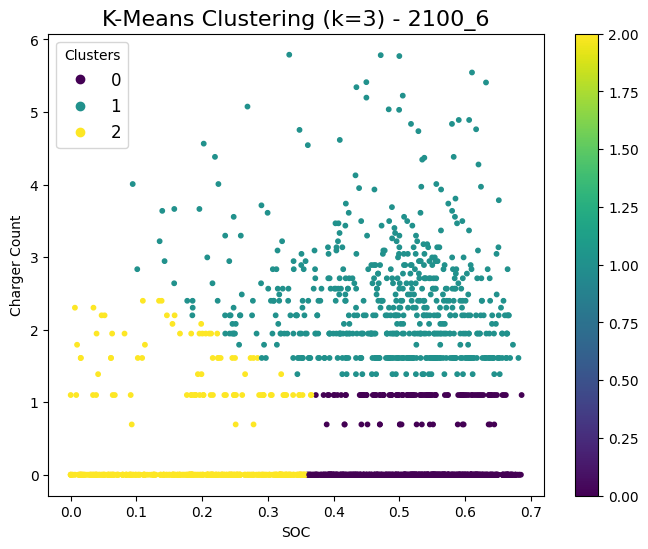

Completed k-means for 2100_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


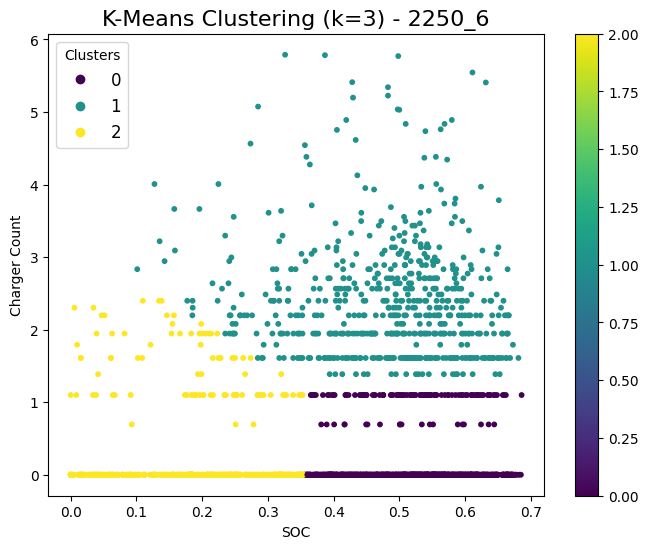

Completed k-means for 2250_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


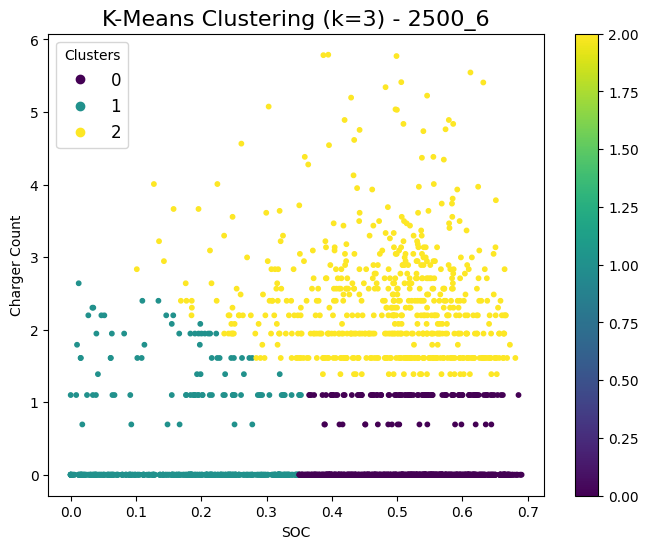

Completed k-means for 2500_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


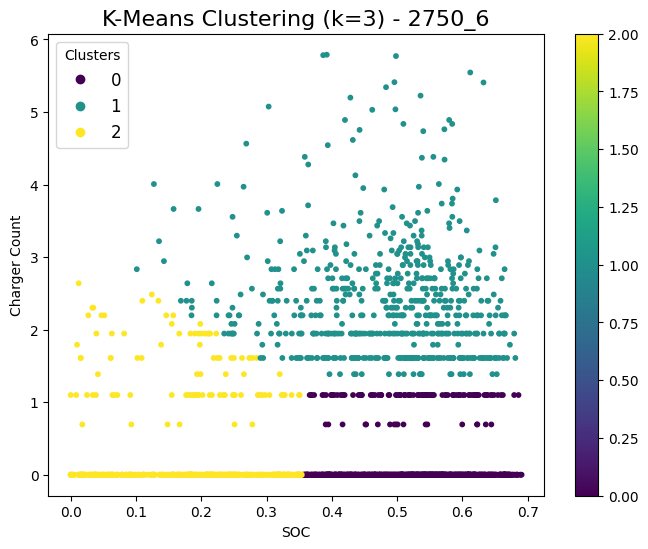

Completed k-means for 2750_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


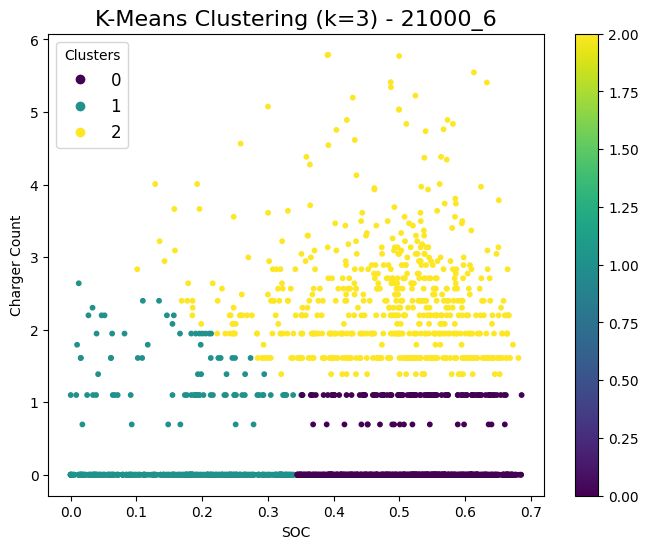

Completed k-means for 21000_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


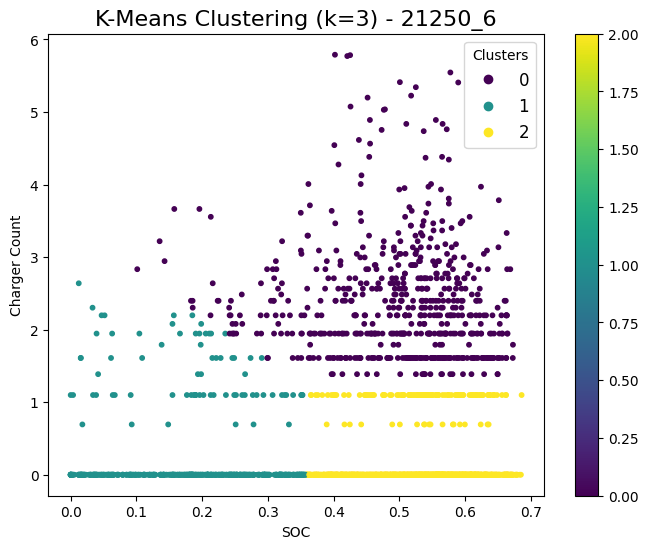

Completed k-means for 21250_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


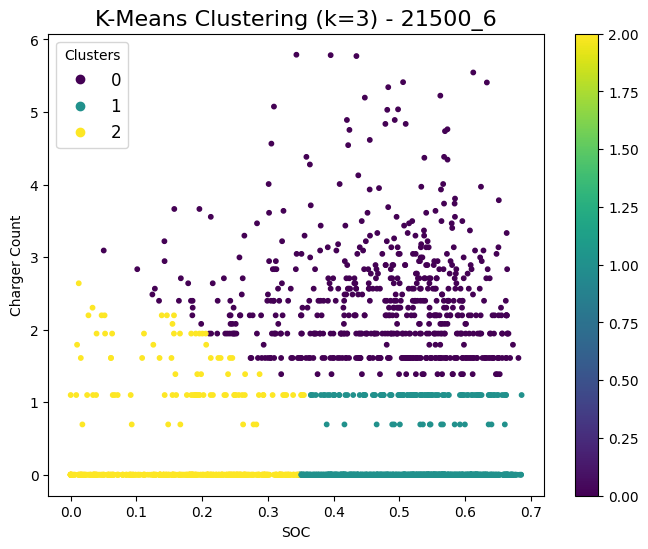

Completed k-means for 21500_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


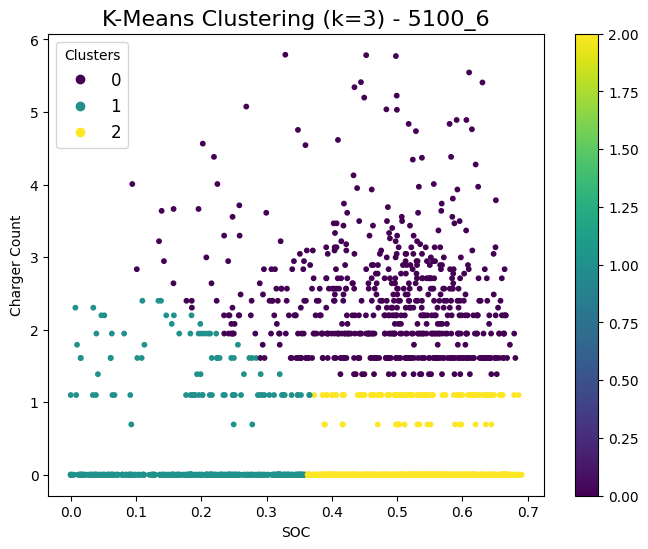

Completed k-means for 5100_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


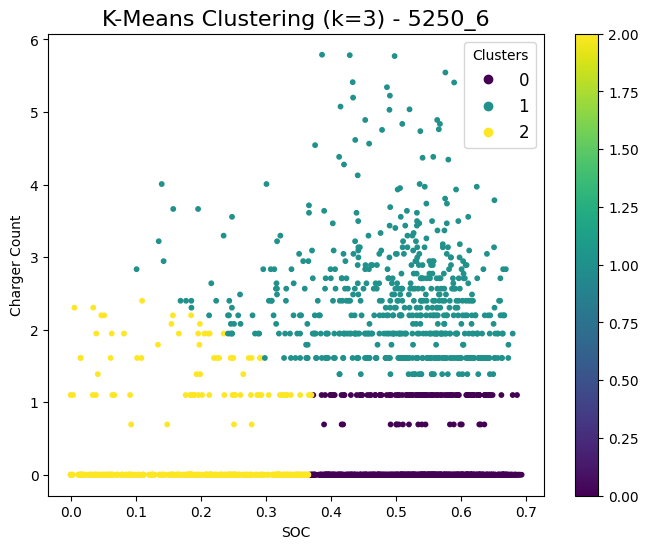

Completed k-means for 5250_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


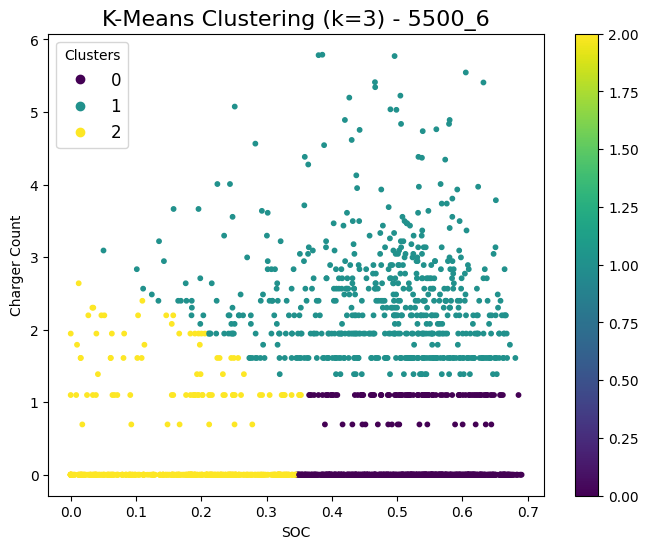

Completed k-means for 5500_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


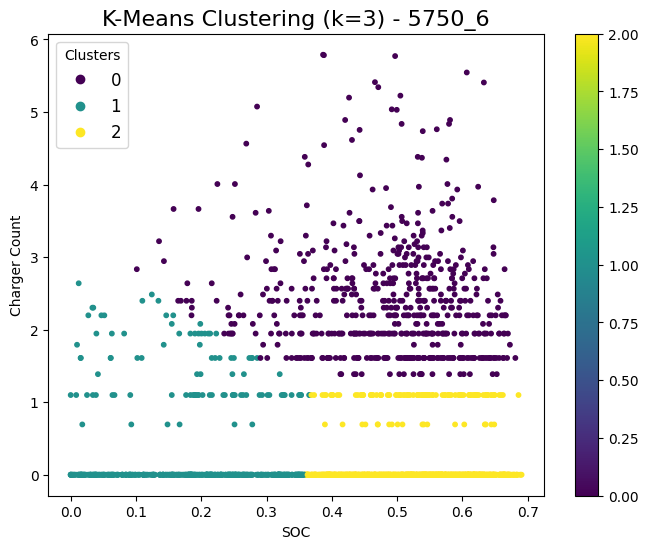

Completed k-means for 5750_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


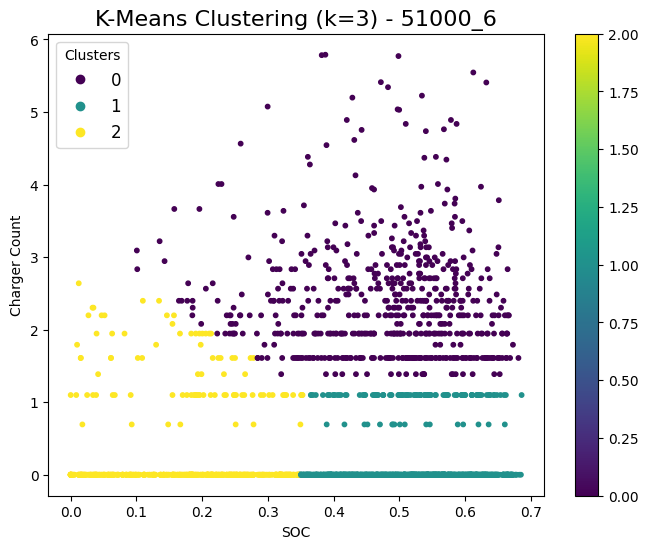

Completed k-means for 51000_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


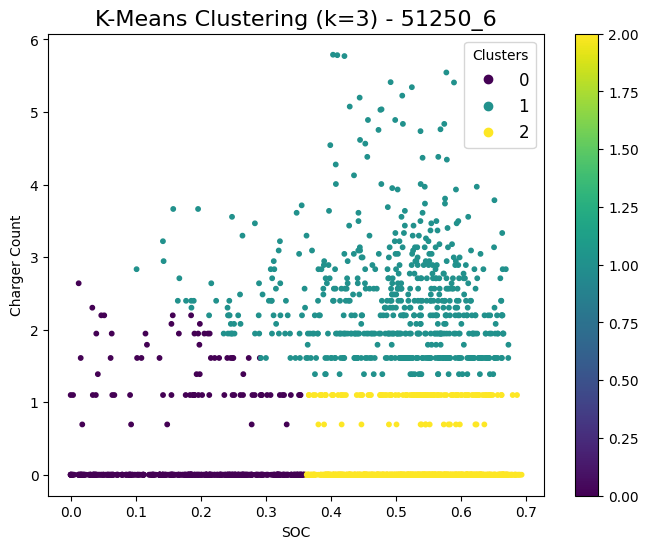

Completed k-means for 51250_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


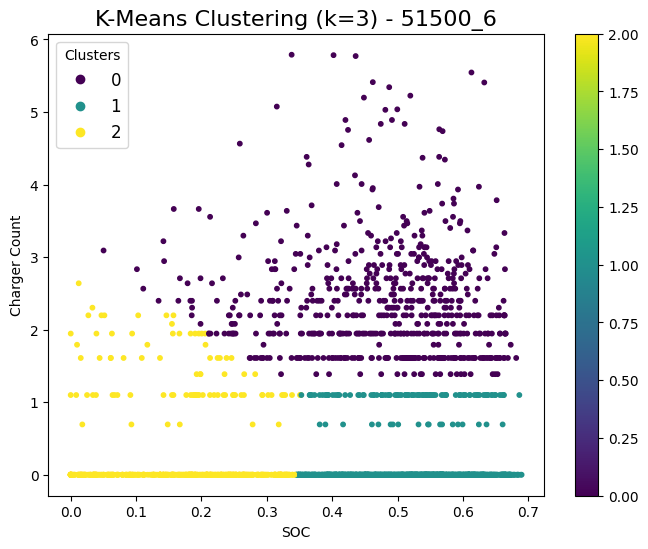

Completed k-means for 51500_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


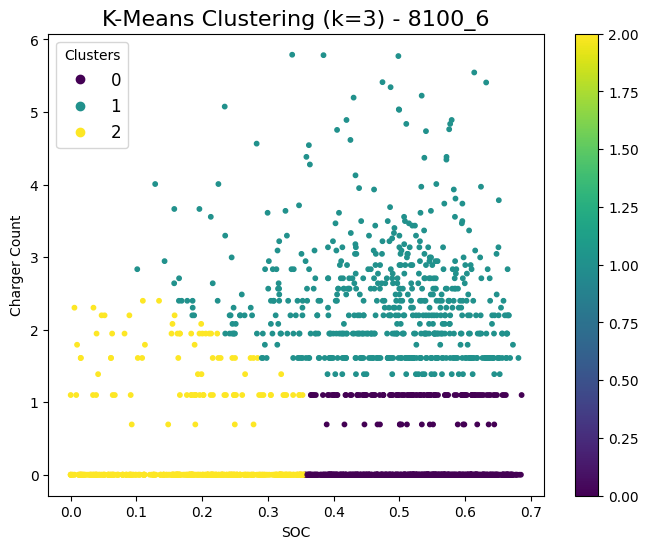

Completed k-means for 8100_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


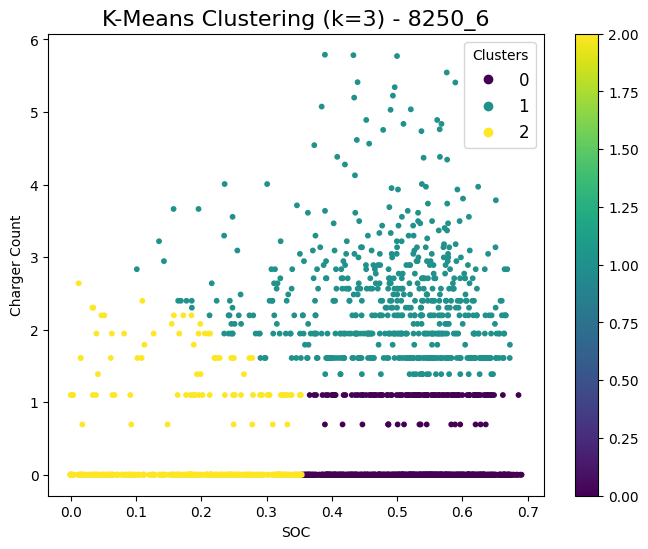

Completed k-means for 8250_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


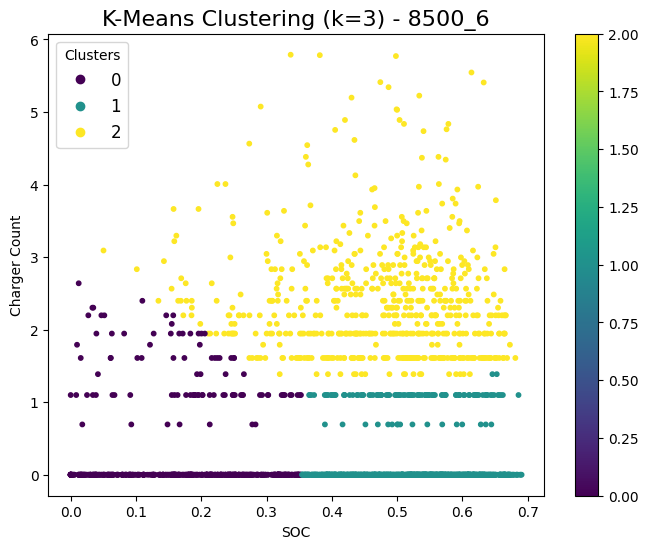

Completed k-means for 8500_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


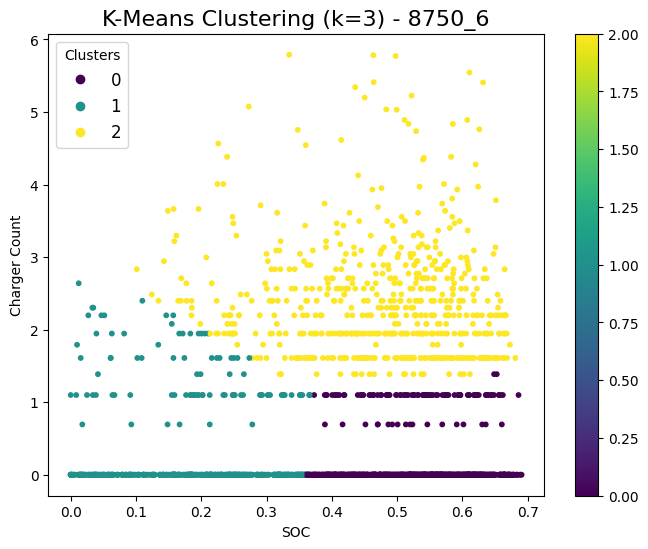

Completed k-means for 8750_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


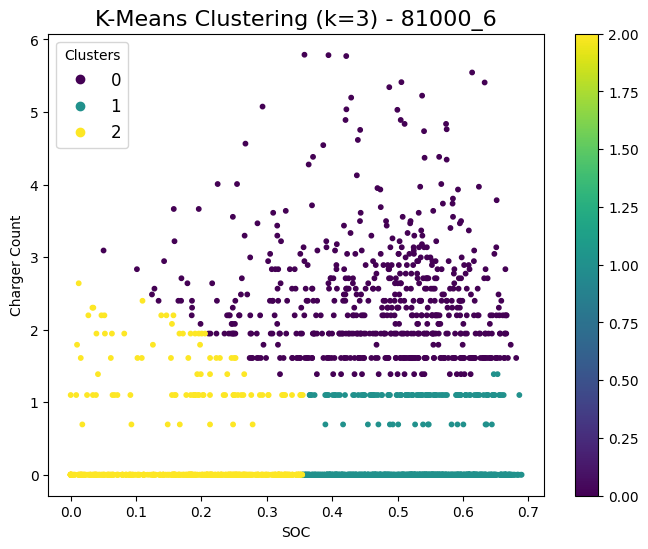

Completed k-means for 81000_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


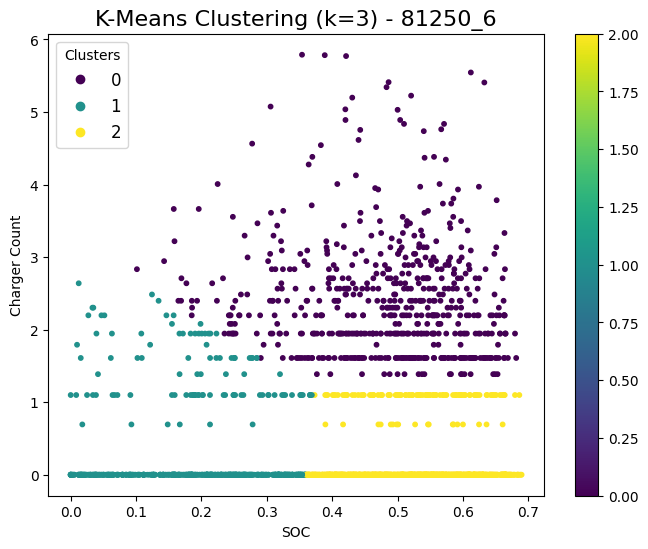

Completed k-means for 81250_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


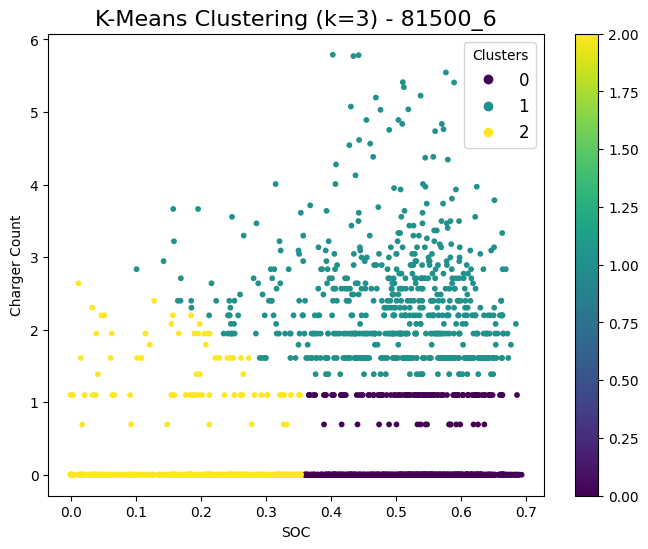

Completed k-means for 81500_6


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


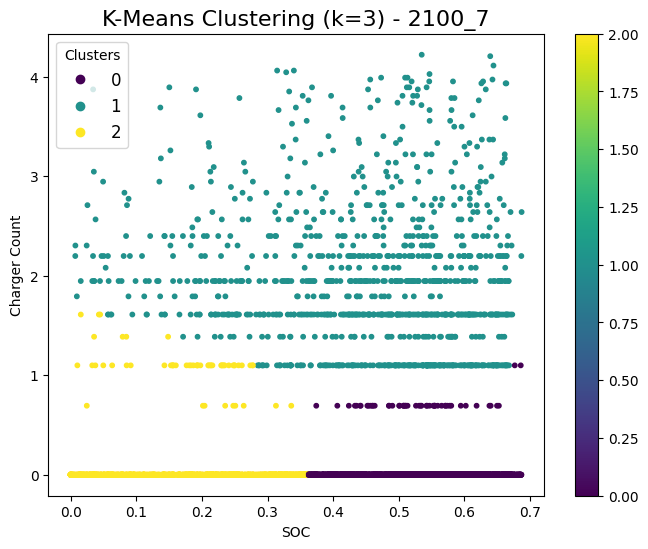

Completed k-means for 2100_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


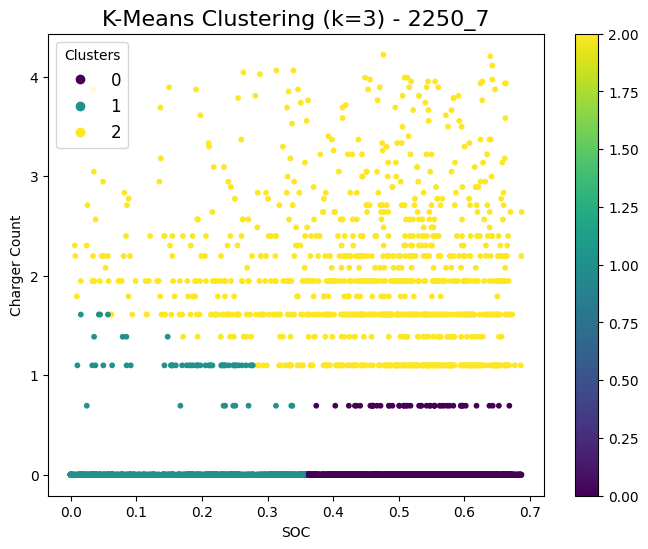

Completed k-means for 2250_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


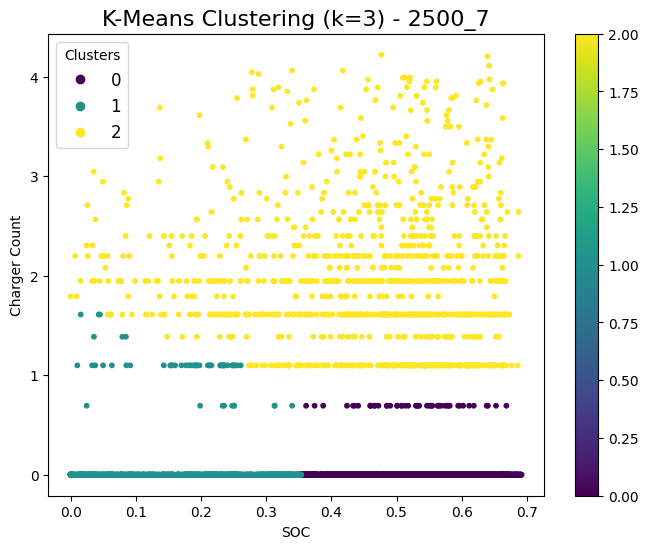

Completed k-means for 2500_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


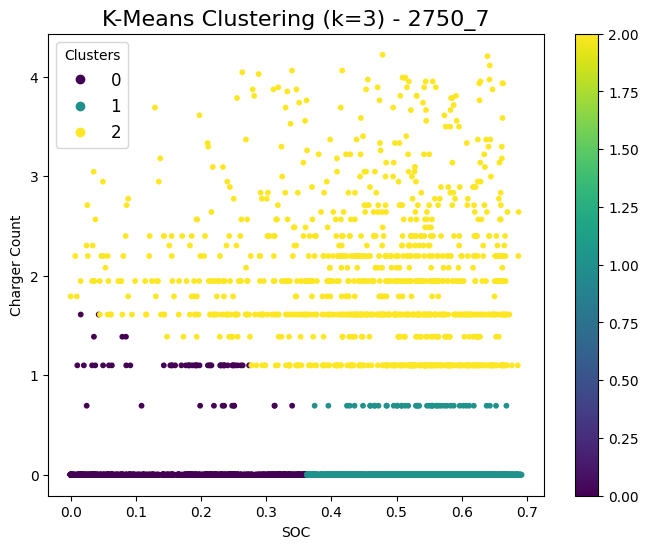

Completed k-means for 2750_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


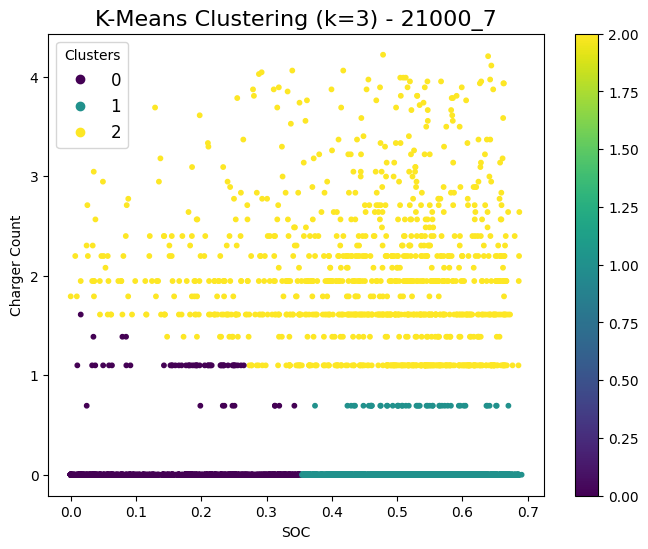

Completed k-means for 21000_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


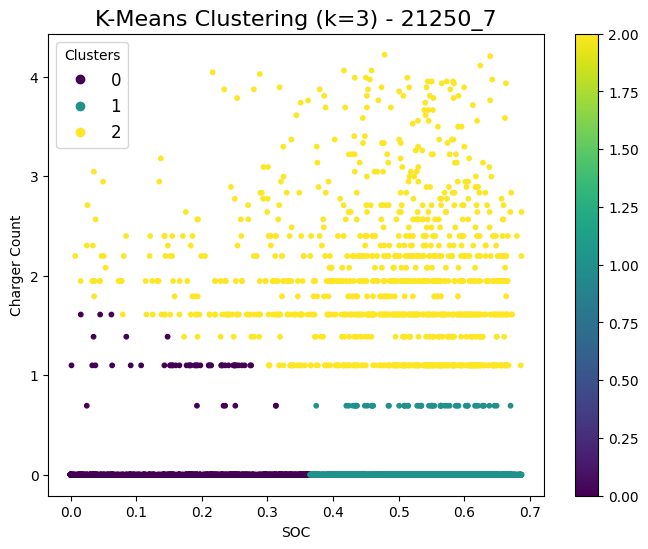

Completed k-means for 21250_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


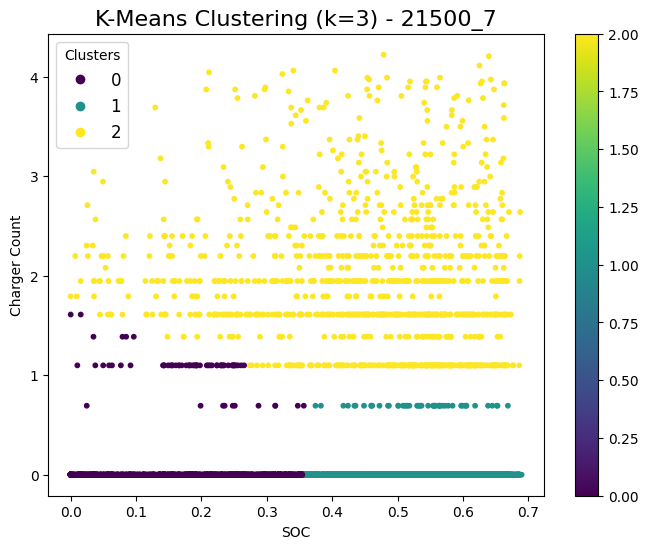

Completed k-means for 21500_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


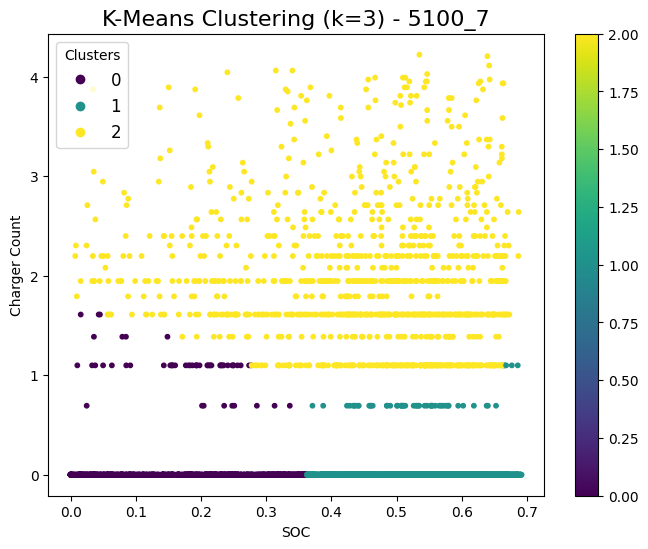

Completed k-means for 5100_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


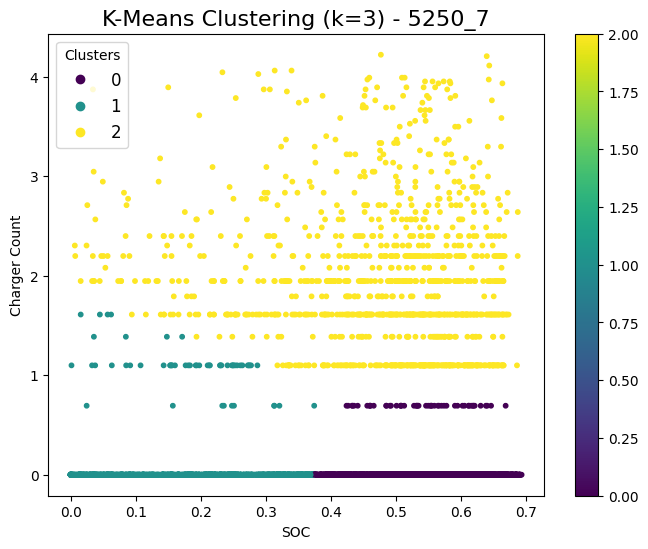

Completed k-means for 5250_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


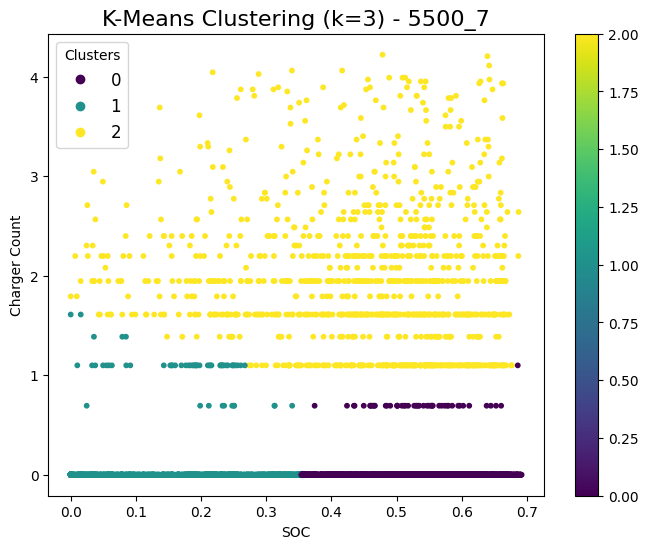

Completed k-means for 5500_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


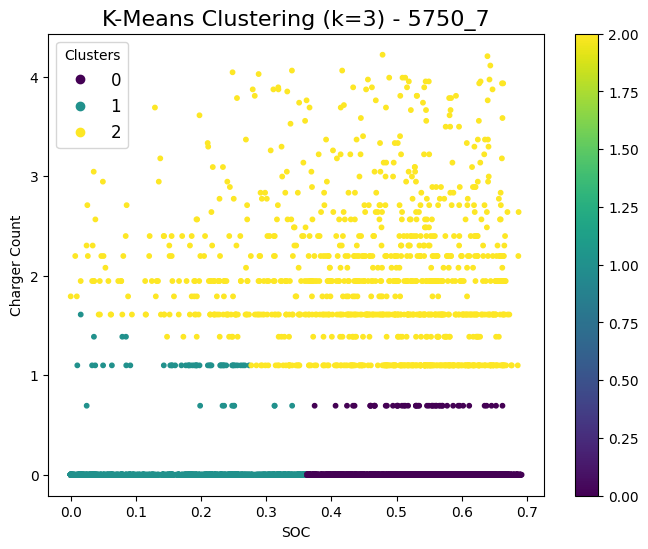

Completed k-means for 5750_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


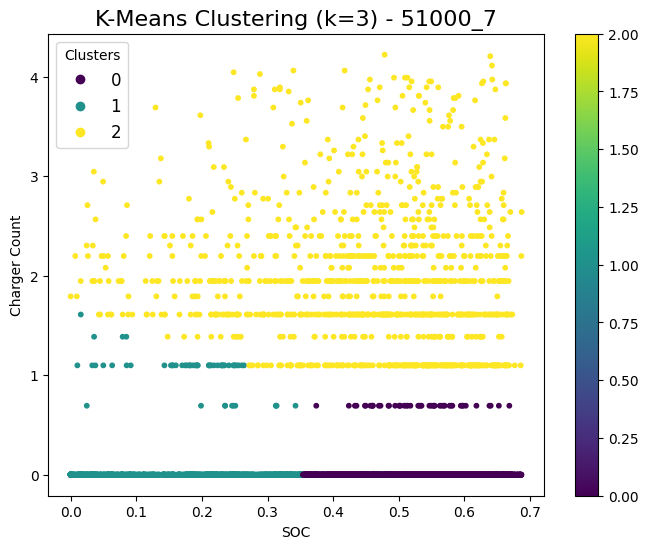

Completed k-means for 51000_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


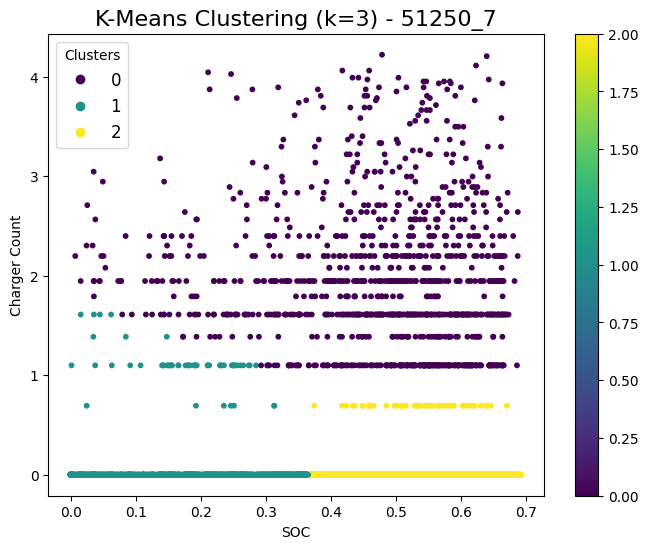

Completed k-means for 51250_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


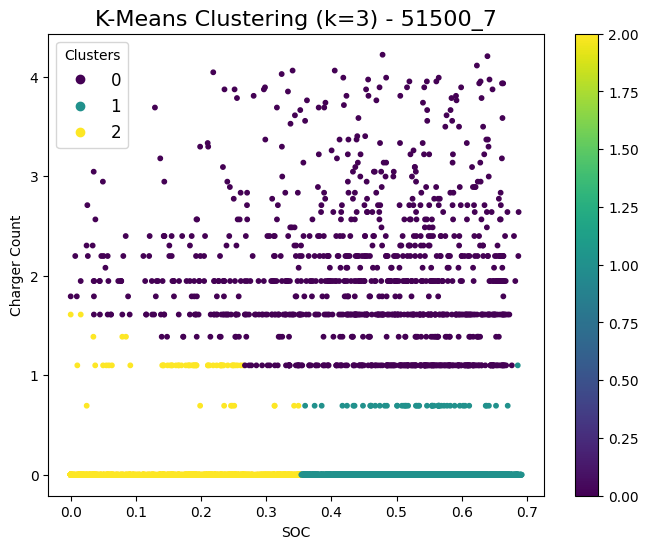

Completed k-means for 51500_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


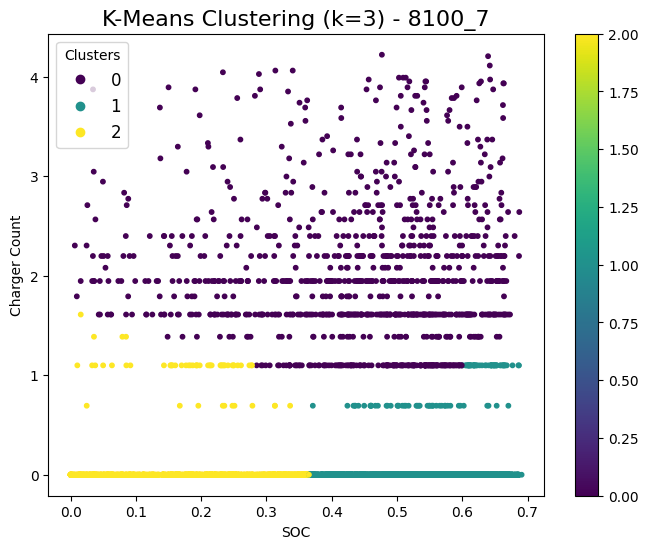

Completed k-means for 8100_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


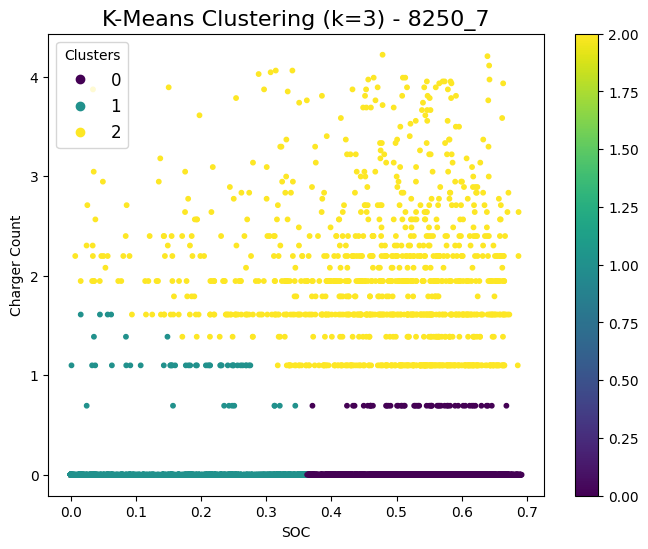

Completed k-means for 8250_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


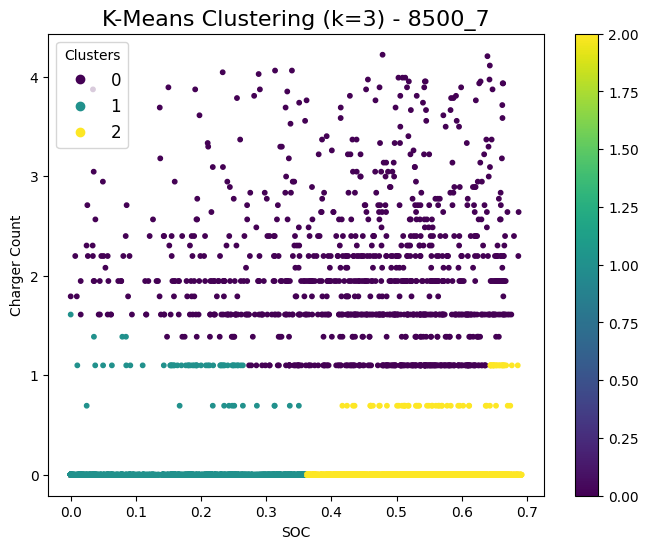

Completed k-means for 8500_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


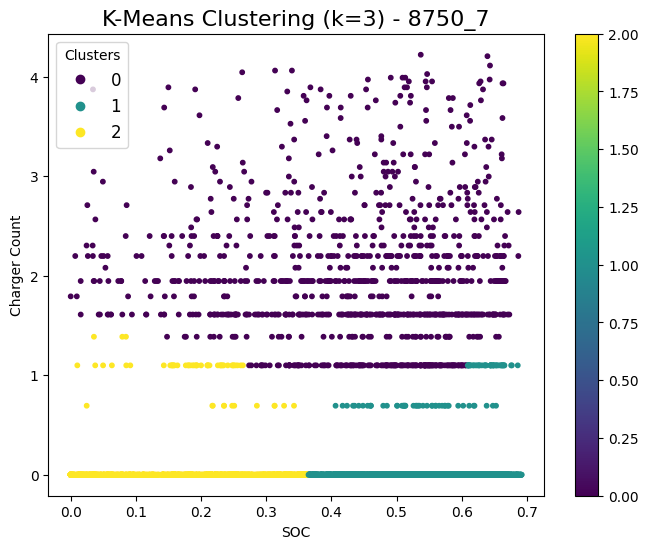

Completed k-means for 8750_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


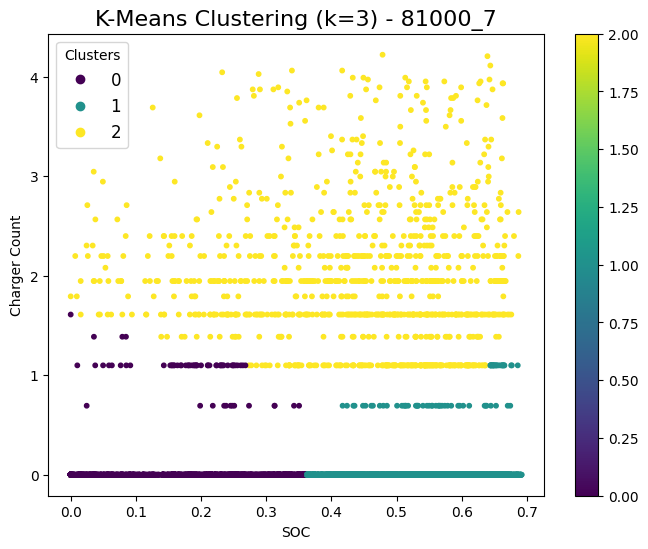

Completed k-means for 81000_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


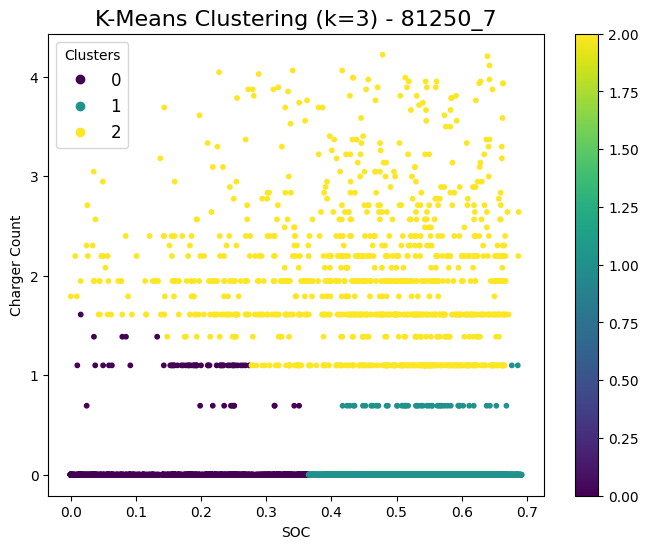

Completed k-means for 81250_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


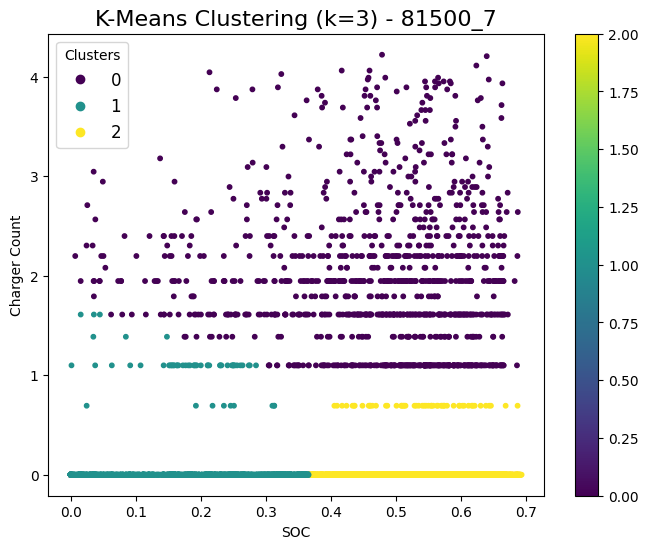

Completed k-means for 81500_7


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


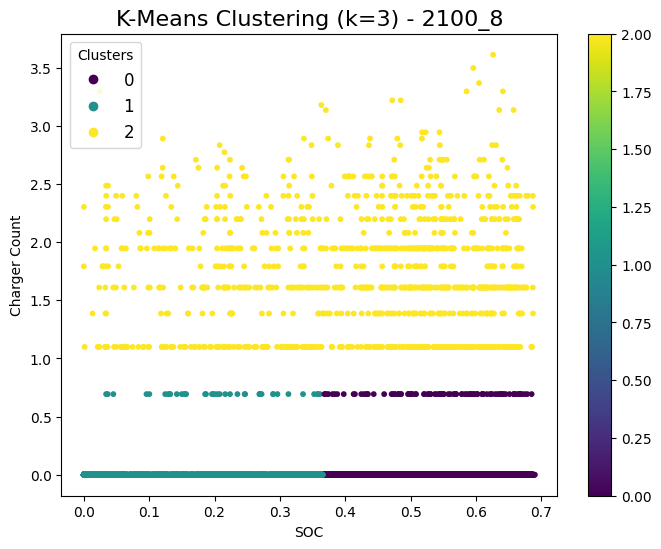

Completed k-means for 2100_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


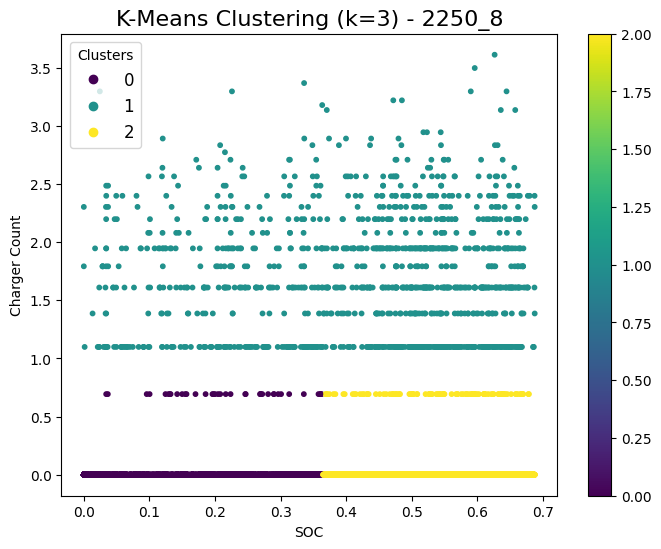

Completed k-means for 2250_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


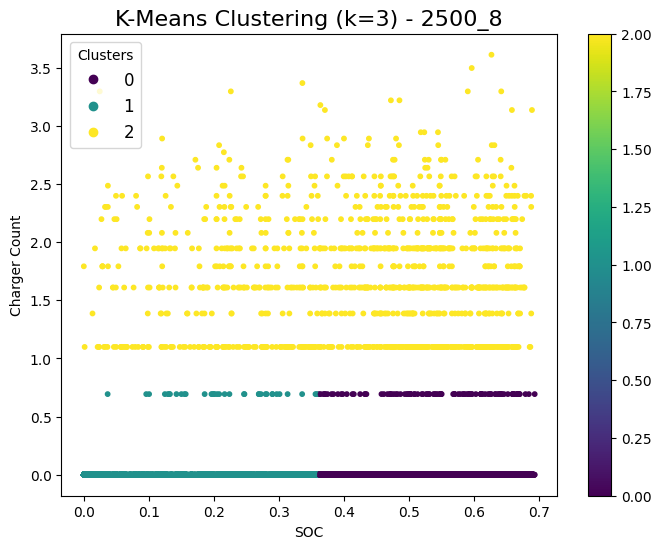

Completed k-means for 2500_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


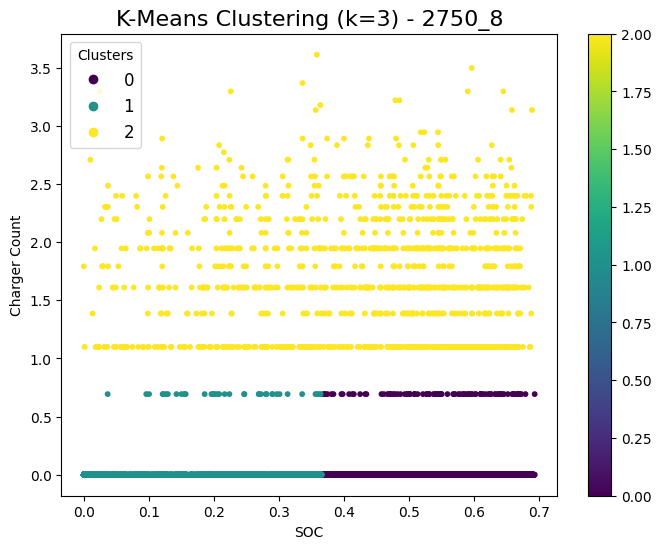

Completed k-means for 2750_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


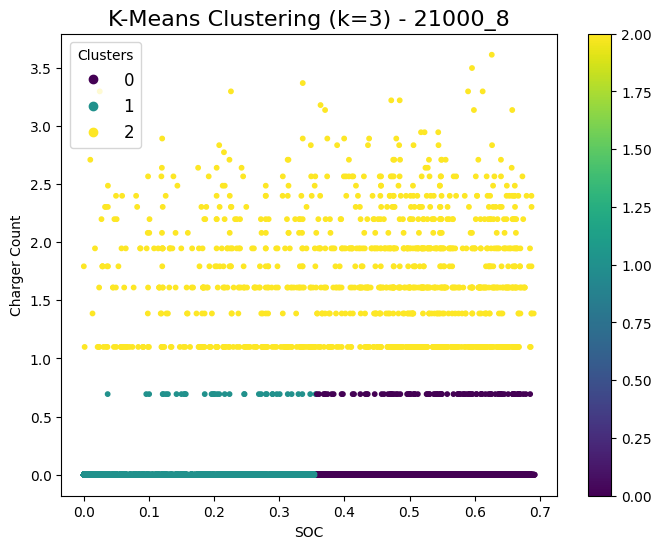

Completed k-means for 21000_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


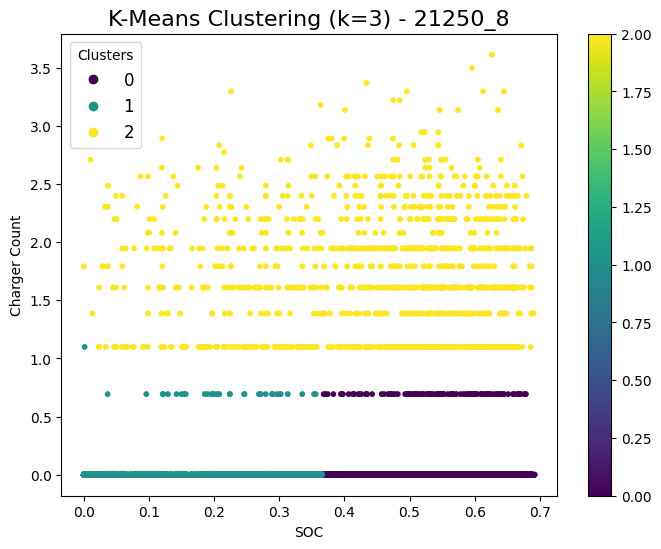

Completed k-means for 21250_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


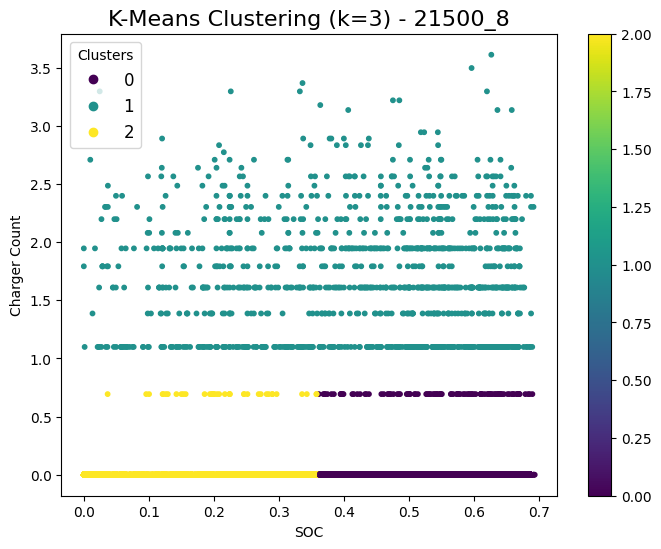

Completed k-means for 21500_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


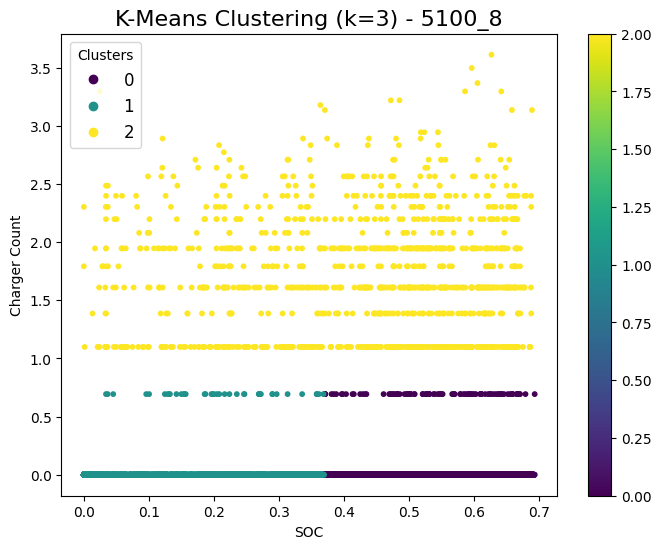

Completed k-means for 5100_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


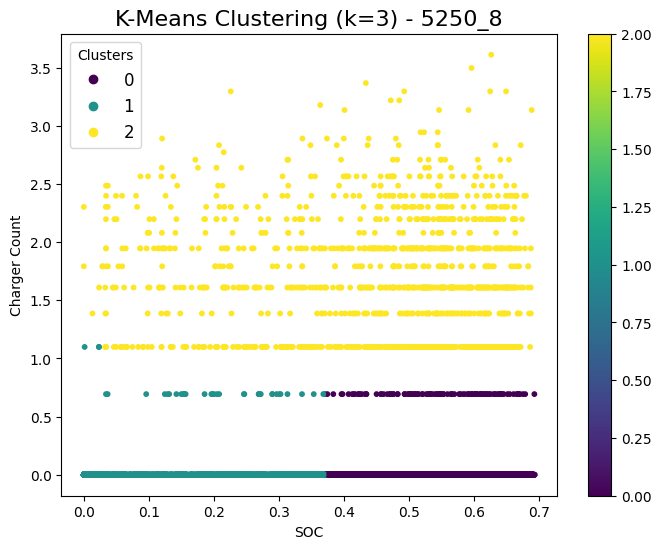

Completed k-means for 5250_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


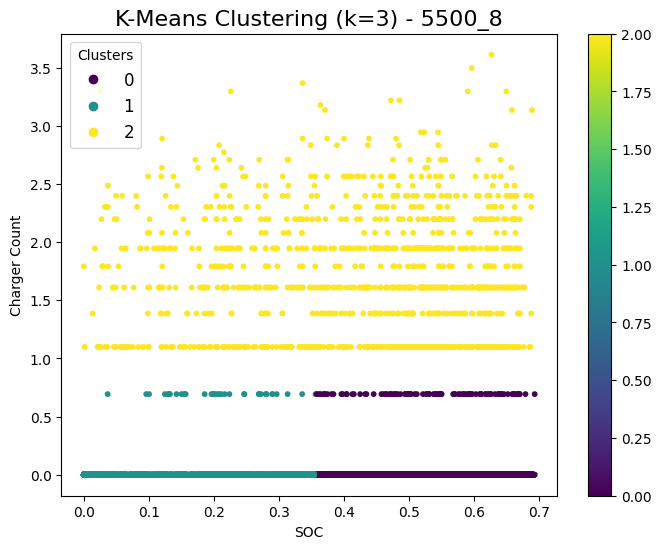

Completed k-means for 5500_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


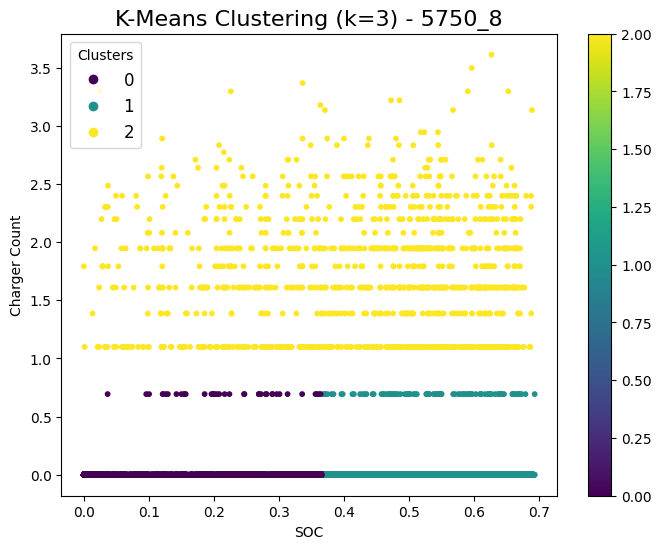

Completed k-means for 5750_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


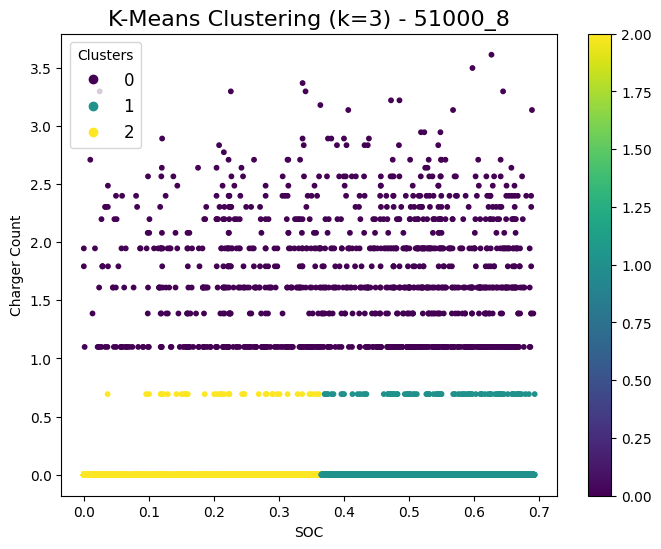

Completed k-means for 51000_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


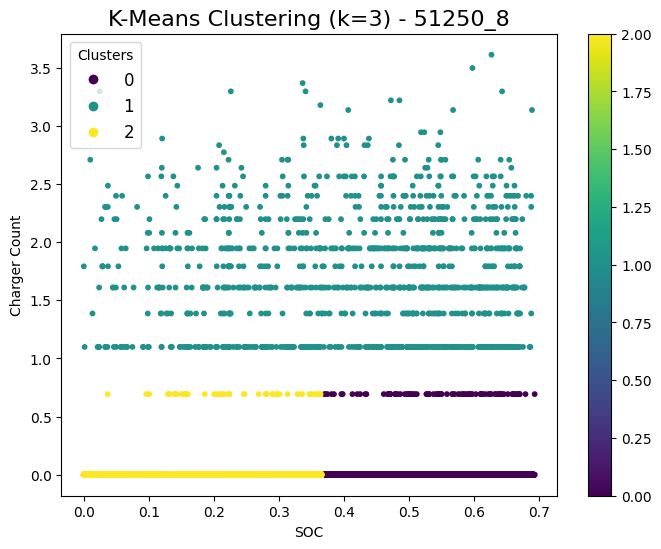

Completed k-means for 51250_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


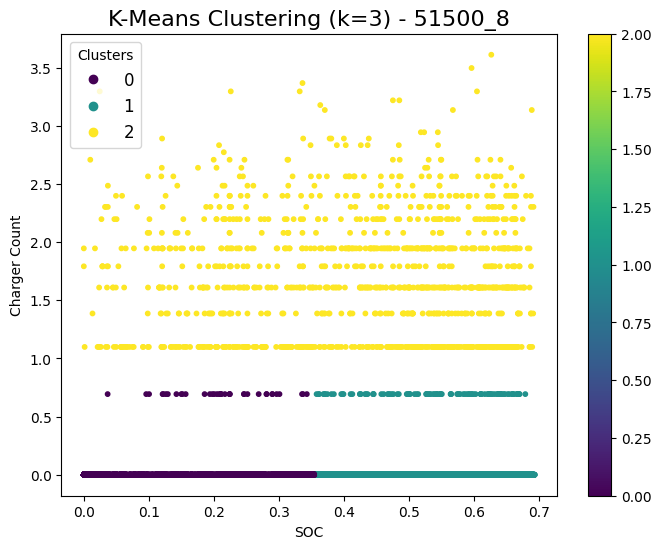

Completed k-means for 51500_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


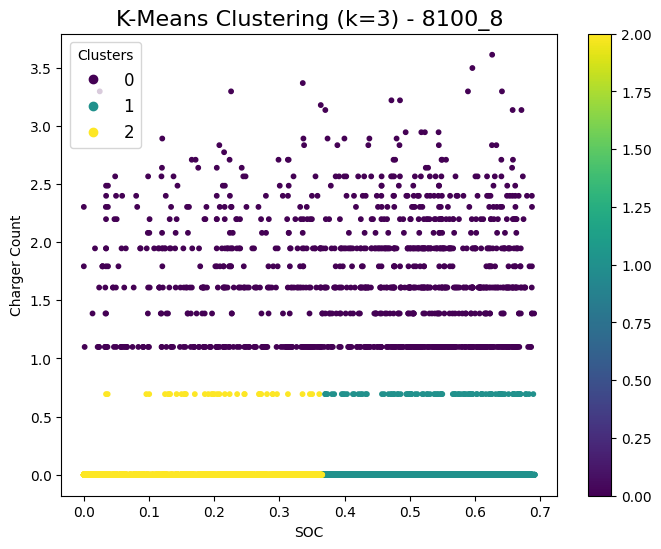

Completed k-means for 8100_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


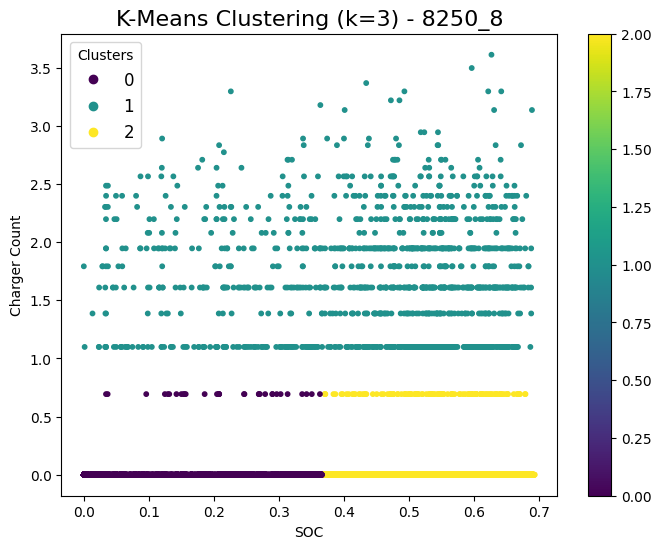

Completed k-means for 8250_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


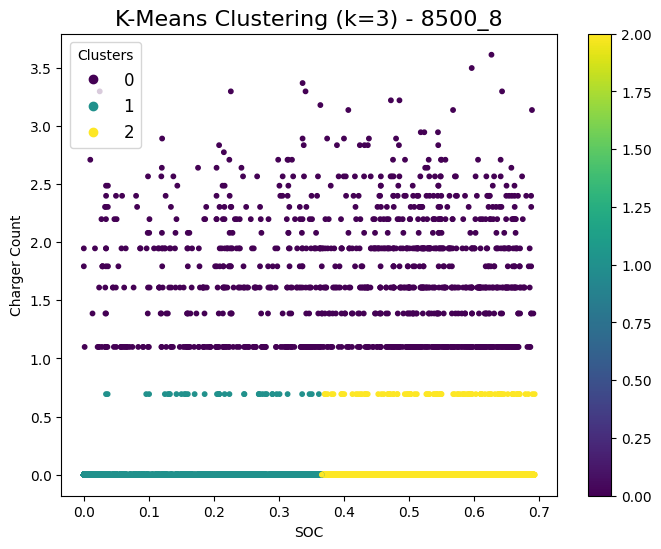

Completed k-means for 8500_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


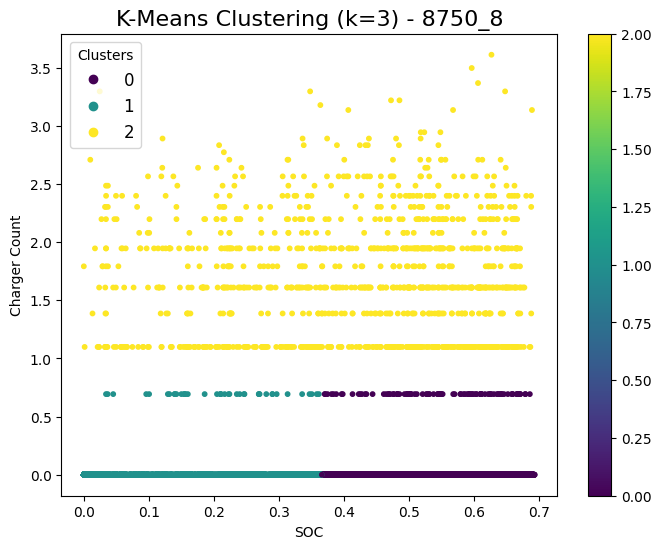

Completed k-means for 8750_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


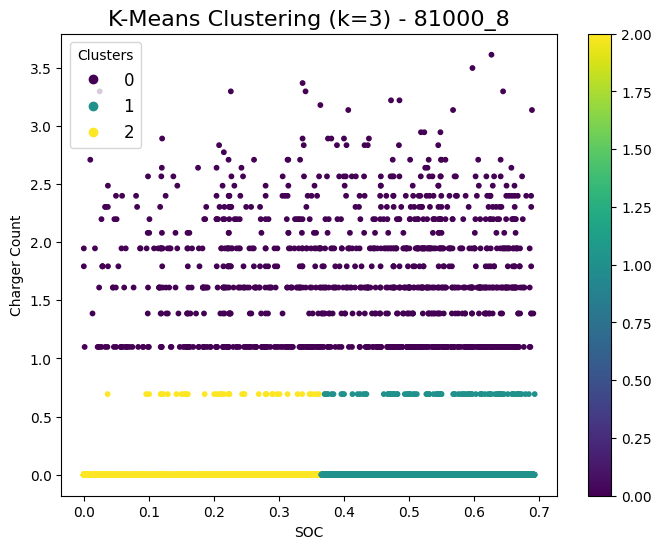

Completed k-means for 81000_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


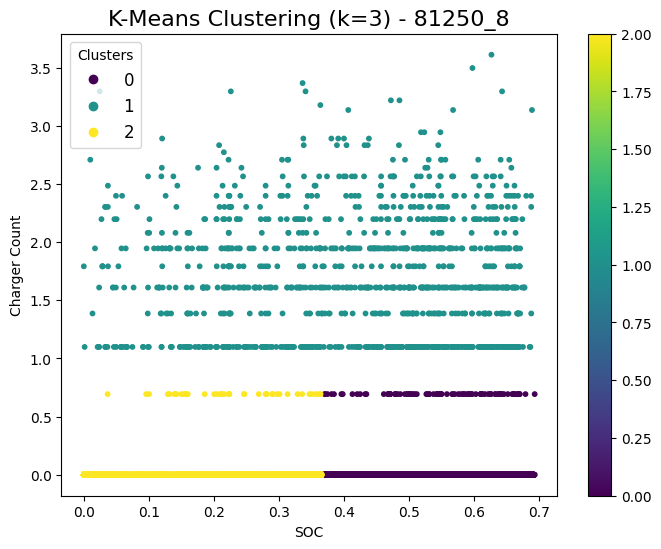

Completed k-means for 81250_8


C:\Users\2755469F\AppData\Local\Temp\ipykernel_25844\2980005217.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_new_selected.to_file(fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp")
C:\Users\2755469F\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lg_NUMPOINTS' to 'lg_NUMPOIN'
  ogr_write(


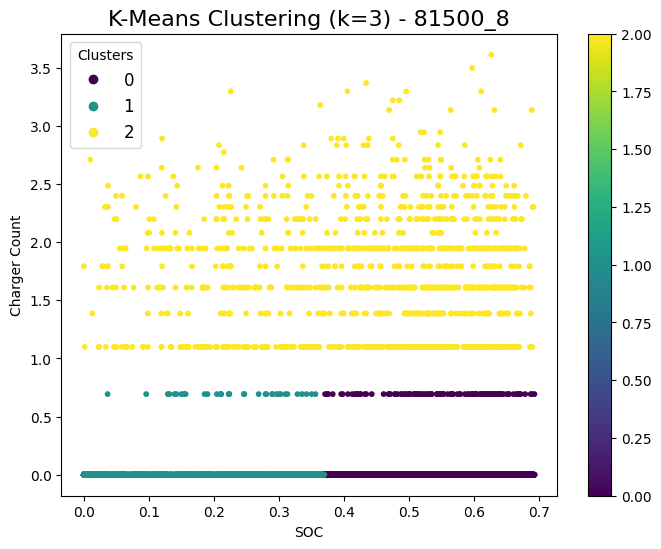

Completed k-means for 81500_8


In [163]:
for resolution in [6, 7, 8]:
    for prefix in ['2', '5', '8']:
        for value in [100, 250, 500, 750, 1000, 1250, 1500]:
            var_name = f'count_{prefix}{value}_{resolution}'
            if var_name in globals():
                df = globals()[var_name]
                analysis_name = f'{prefix}{value}_{resolution}'
                kmeans_analysis_3clusters(df, analysis_name)
                print(f"Completed k-means for {analysis_name}")

In [153]:
kmeans_results = {}

for resolution in [6, 7, 8]:
    for prefix in ['2', '5', '8']:
        for value in [100, 250, 500, 750, 1000, 1250, 1500]:
            name = f'{prefix}{value}_{resolution}'
            file_path = fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp"
            
            try:
                kmeans_results[name] = gpd.read_file(file_path)
                globals()[f'kmeans_{name}'] = kmeans_results[name]
            except FileNotFoundError:
                print(f"File not found: {name}")
                continue

In [ ]:
for resolution in [6, 7, 8]:
    name = f'benchmark_{resolution}'
    file_path = fr"E:\Zixin\Optimisation\case\charging_desert\kmeans_3clusters_{name}.shp"
    
    try:
        kmeans_results[name] = gpd.read_file(file_path)
        globals()[f'kmeans_{name}'] = kmeans_results[name]
    except FileNotFoundError:
        print(f"Benchmark file not found: {name}")
        continue

sample variable names kmeans_benchmark_6 kmeans_2100_6

In [167]:
search_dict = {'2100_6': 2,
'2250_6': 2,
'2500_6': 1,
'2750_6': 2,
'21000_6': 1,
'21250_6': 1,
'21500_6': 2,
'5100_6': 1,
'5250_6': 2,
'5500_6': 2,
'5750_6': 1,
'51000_6': 2,
'51250_6': 0,
'51500_6': 2,
'8100_6': 2,
'8250_6': 2,
'8500_6': 0,
'8750_6': 1,
'81000_6': 2,
'81250_6': 1,
'81500_6': 2,
'2100_7': 2,
'2250_7': 1,
'2500_7': 1,
'2750_7': 0,
'21000_7': 0,
'21250_7': 0,
'21500_7': 0,
'5100_7': 0,
'5250_7': 1,
'5500_7': 1,
'5750_7': 1,
'51000_7': 1,
'51250_7': 1,
'51500_7': 2,
'8100_7': 2,
'8250_7': 1,
'8500_7': 1,
'8750_7': 2,
'81000_7': 0,
'81250_7': 0,
'81500_7': 1,
'2100_8': 1,
'2250_8': 0,
'2500_8': 1,
'2750_8': 1,
'21000_8': 1,
'21250_8': 1,
'21500_8': 2,
'5100_8': 1,
'5250_8': 1,
'5500_8': 1,
'5750_8': 0,
'51000_8': 2,
'51250_8': 2,
'51500_8': 0,
'8100_8': 2,
'8250_8': 0,
'8500_8': 1,
'8750_8': 1,
'81000_8': 2,
'81250_8': 2,
'81500_8': 1}

In [168]:
successful = 0
failed = []

for scenario, target_cluster in search_dict.items():
    var_name = f'kmeans_{scenario}'
    
    try:
        gdf = globals()[var_name]
        gdf['cluster_new'] = (gdf['cluster'] == target_cluster).astype(int)
        globals()[var_name] = gdf

        if 'kmeans_results' in globals() and scenario in kmeans_results:
            kmeans_results[scenario]['cluster_new'] = (kmeans_results[scenario]['cluster'] == target_cluster).astype(int)
        
        successful += 1
    except KeyError:
        failed.append(scenario)

print(f"\nSuccessfully updated {successful} scenarios")
if failed:
    print(f"Failed scenarios: {failed}")



Successfully updated 63 scenarios


In [ ]:
import os

output_dir = r"E:\Zixin\Optimisation\case\charging_desert\cluster"
os.makedirs(output_dir, exist_ok=True)

saved_count = 0
failed_saves = []

for scenario in search_dict.keys():
    var_name = f'kmeans_{scenario}'
    
    if var_name in globals():
        try:
            gdf = globals()[var_name]

            output_path = os.path.join(output_dir, f'cluster_{scenario}.shp')
            gdf.to_file(output_path)
            
            saved_count += 1
            print(f"Saved: {scenario}")
            
        except Exception as e:
            failed_saves.append((scenario, str(e)))
            print(f"Failed to save {scenario}: {e}")
    else:
        print(f"Variable not found: {var_name}")


In [ ]:
for scenario, target_cluster in search_dict_benchmark.items():
    var_name = f'kmeans_{scenario}'
    
    if var_name in globals():
        gdf = globals()[var_name]

        gdf['cluster_new'] = (gdf['cluster'] == target_cluster).astype(int)

        globals()[var_name] = gdf
        
        print(f"{scenario}: {gdf['cluster_new'].sum()} points assigned to cluster_new=1")

output_dir = r"E:\Zixin\Optimisation\case\charging_desert\cluster"
os.makedirs(output_dir, exist_ok=True)

for scenario in search_dict_benchmark.keys():
    var_name = f'kmeans_{scenario}'
    
    if var_name in globals():
        try:
            gdf = globals()[var_name]
            output_path = os.path.join(output_dir, f'cluster_{scenario}.shp')
            gdf.to_file(output_path)
            print(f"Saved: {scenario}")
        except Exception as e:
            print(f"Failed to save {scenario}: {e}")

print(f"\nAll benchmark files saved to: {output_dir}")

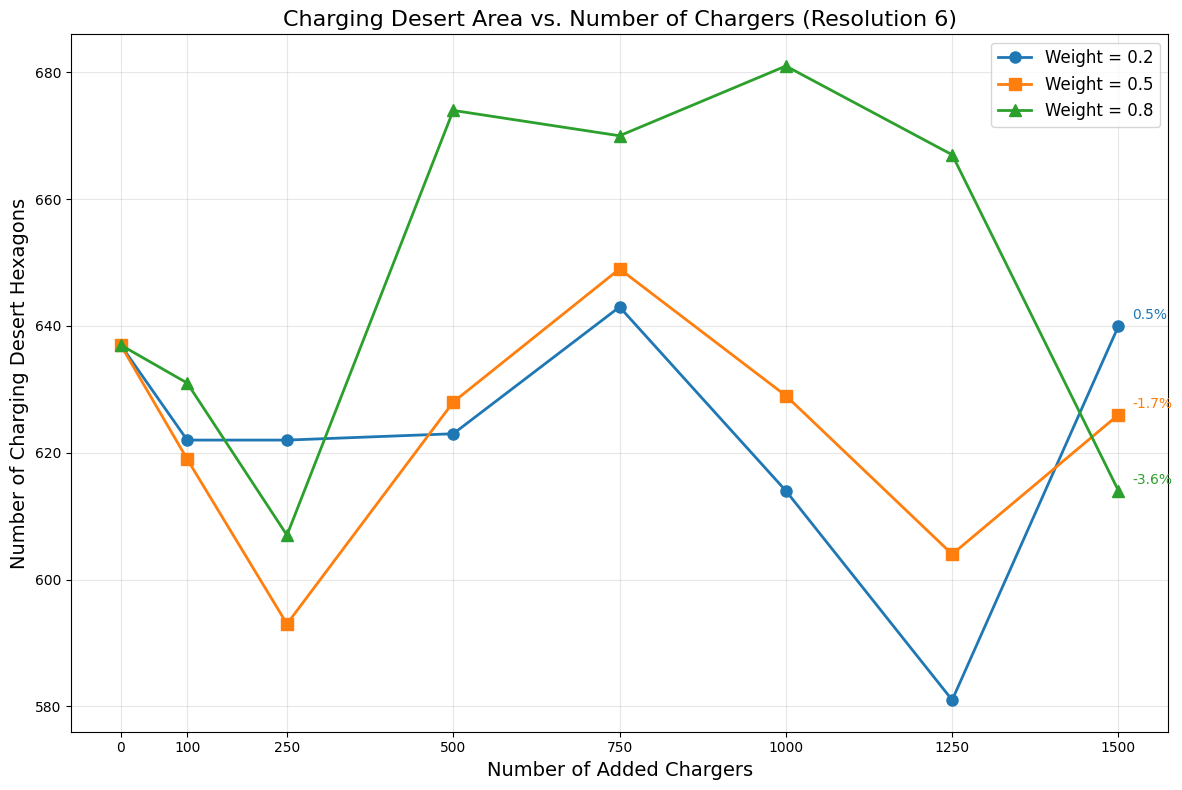


Charging Desert Hexagon Counts (Resolution 6):
------------------------------------------------------------
Chargers	Weight=0.2	Weight=0.5	Weight=0.8
------------------------------------------------------------
0		637		637		637		
100		622		619		631		
250		622		593		607		
500		623		628		674		
750		643		649		670		
1000		614		629		681		
1250		581		604		667		
1500		640		626		614		


In [175]:
import matplotlib.pyplot as plt
import numpy as np

# Define the data structure
charger_counts = [0, 100, 250, 500, 750, 1000, 1250, 1500]  # 0 for benchmark
weights = [0.2, 0.5, 0.8]
weight_map = {2: 0.2, 5: 0.5, 8: 0.8}

# Calculate charging desert areas for resolution 6
results = {0.2: [], 0.5: [], 0.8: []}

# Process benchmark (0 chargers)
for weight in weights:
    var_name = 'kmeans_benchmark_6'
    if var_name in globals():
        gdf = globals()[var_name]
        desert_count = gdf['cluster_new'].sum()
        results[weight].append(desert_count)

# Process scenarios
for weight_code, weight_val in [(2, 0.2), (5, 0.5), (8, 0.8)]:
    for chargers in charger_counts[1:]:  # Skip 0 as that's benchmark
        var_name = f'kmeans_{weight_code}{chargers}_6'
        if var_name in globals():
            gdf = globals()[var_name]
            desert_count = gdf['cluster_new'].sum()
            results[weight_val].append(desert_count)
        else:
            print(f"Missing: {var_name}")

# Create line plot
plt.figure(figsize=(12, 8))

colors = {0.2: '#1f77b4', 0.5: '#ff7f0e', 0.8: '#2ca02c'}
markers = {0.2: 'o', 0.5: 's', 0.8: '^'}

for weight in weights:
    if len(results[weight]) == len(charger_counts):
        plt.plot(charger_counts, results[weight], 
                color=colors[weight], 
                marker=markers[weight], 
                markersize=8,
                linewidth=2,
                label=f'Weight = {weight}')

plt.xlabel('Number of Added Chargers', fontsize=14)
plt.ylabel('Number of Charging Desert Hexagons', fontsize=14)
plt.title('Charging Desert Area vs. Number of Chargers (Resolution 6)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(charger_counts)

# Add percentage change annotation
for weight in weights:
    if len(results[weight]) == len(charger_counts):
        initial = results[weight][0]
        final = results[weight][-1]
        change_pct = (final - initial) / initial * 100
        plt.annotate(f'{change_pct:.1f}%', 
                    xy=(charger_counts[-1], final),
                    xytext=(10, 5), 
                    textcoords='offset points',
                    fontsize=10,
                    color=colors[weight])

plt.tight_layout()
# plt.savefig(r'E:\Zixin\Optimisation\case\Figs\charging_desert_change_res6.png', dpi=300)
plt.show()

# Print summary statistics
print("\nCharging Desert Hexagon Counts (Resolution 6):")
print("-" * 60)
print("Chargers\tWeight=0.2\tWeight=0.5\tWeight=0.8")
print("-" * 60)
for i, chargers in enumerate(charger_counts):
    row = f"{chargers}\t\t"
    for weight in weights:
        if i < len(results[weight]):
            row += f"{results[weight][i]}\t\t"
    print(row)

In [1]:
# Analyze all resolutions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
resolutions = [6, 7, 8]

for idx, resolution in enumerate(resolutions):
    ax = axes[idx]
    results = {0.2: [], 0.5: [], 0.8: []}
    
    # Process benchmark
    for weight in weights:
        var_name = f'kmeans_benchmark_{resolution}'
        if var_name in globals():
            gdf = globals()[var_name]
            results[weight].append(gdf['cluster_new'].sum())
    
    # Process scenarios
    for weight_code, weight_val in [(2, 0.2), (5, 0.5), (8, 0.8)]:
        for chargers in charger_counts[1:]:
            var_name = f'kmeans_{weight_code}{chargers}_{resolution}'
            if var_name in globals():
                gdf = globals()[var_name]
                results[weight_val].append(gdf['cluster_new'].sum())
    
    # Plot
    for weight in weights:
        if len(results[weight]) == len(charger_counts):
            ax.plot(charger_counts, results[weight], 
                   color=colors[weight], 
                   marker=markers[weight], 
                   markersize=8,
                   linewidth=2,
                   label=f'Weight = {weight}')
    
    ax.set_xlabel('Number of Added Chargers', fontsize=12)
    ax.set_ylabel('Charging Desert Hexagons', fontsize=12)
    ax.set_title(f'Resolution {resolution}', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(charger_counts)
    ax.tick_params(axis='x', rotation=45)
    
    if idx == 0:
        ax.legend(fontsize=10)

plt.suptitle('Charging Desert Changes Across Different H3 Resolutions', fontsize=16)
plt.tight_layout()
# plt.savefig(r'E:\Zixin\Optimisation\case\Figs\charging_desert_all_resolutions.png', dpi=300)
plt.show()

NameError: name 'plt' is not defined

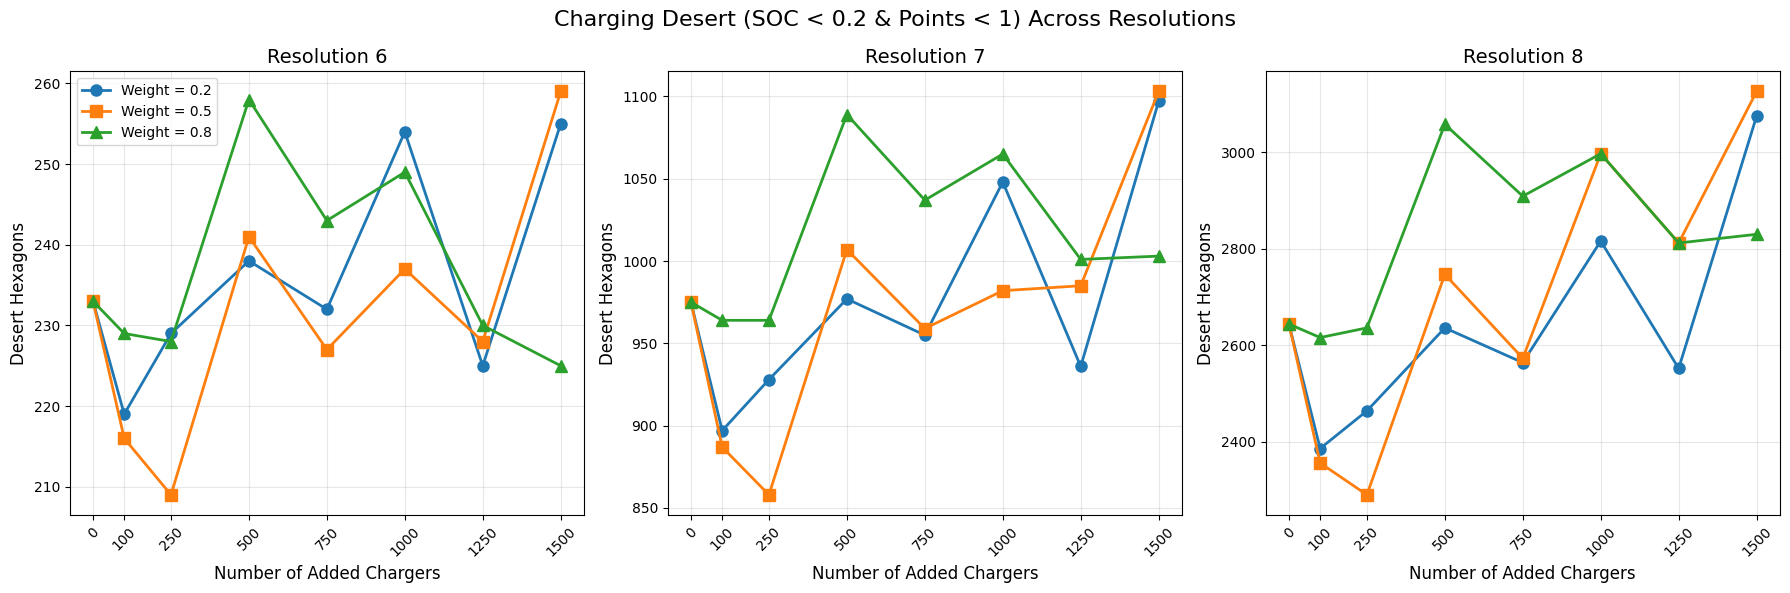

In [ ]:
charger_counts = [0, 100, 250, 500, 750, 1000, 1250, 1500]  # 0 for benchmark
weights = [0.2, 0.5, 0.8]
weight_map = {2: 0.2, 5: 0.5, 8: 0.8}
resolutions = [6, 7, 8]

def count_charging_desert(gdf, soc_threshold=0.2, numpoints_threshold=1):
    desert_mask = (gdf['soc_def'] < soc_threshold) & (gdf['NUMPOINTS'] < numpoints_threshold)
    return desert_mask.sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, resolution in enumerate(resolutions):
    ax = axes[idx]
    results = {0.2: [], 0.5: [], 0.8: []}
    
    # Benchmark
    var_name = f'count_benchmark_{resolution}'
    if var_name in globals():
        gdf = globals()[var_name]
        desert_count = count_charging_desert(gdf)
        for weight in weights:
            results[weight].append(desert_count)
    
    # Scenarios
    for weight_code, weight_val in [(2, 0.2), (5, 0.5), (8, 0.8)]:
        for chargers in charger_counts[1:]:
            var_name = f'count_{weight_code}{chargers}_{resolution}'
            if var_name in globals():
                gdf = globals()[var_name]
                desert_count = count_charging_desert(gdf)
                results[weight_val].append(desert_count)
    
    # Plot
    for weight in weights:
        if len(results[weight]) == len(charger_counts):
            ax.plot(charger_counts, results[weight], 
                   color=colors[weight], 
                   marker=markers[weight], 
                   markersize=8,
                   linewidth=2,
                   label=f'Weight = {weight}')
    
    ax.set_xlabel('Number of Added Chargers', fontsize=12)
    ax.set_ylabel('Desert Hexagons', fontsize=12)
    ax.set_title(f'Resolution {resolution}', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(charger_counts)
    ax.tick_params(axis='x', rotation=45)
    
    if idx == 0:
        ax.legend(fontsize=10)

plt.suptitle('Charging Desert (SOC < 0.2 & Points < 1) Across Resolutions', fontsize=16)
plt.tight_layout()

plt.show()